In [24]:
import numpy as np
import pandas as pd

# Number of samples
n_samples = 1000

# Input ranges
input_ranges = {
    "Network_Latency": [0, 200],
    "Bandwidth_Utilisation": [0, 100],
    "Packet_Loss_Rate": [0, 10],
    "CPU_Usage": [0, 100],
    "Memory_Usage": [0, 100],
}

# Helper: random generation within range
def generate_inputs(n_samples, ranges):
    data = {}
    for key, (low, high) in ranges.items():
        # Generate random numbers with some distribution to simulate realistic scenarios
        if key == "Network_Latency":
            data[key] = np.random.normal(loc=50, scale=40, size=n_samples).clip(low, high)
        elif key == "Bandwidth_Utilisation":
            data[key] = np.random.normal(loc=60, scale=20, size=n_samples).clip(low, high)
        elif key == "Packet_Loss_Rate":
            data[key] = np.random.exponential(scale=1.5, size=n_samples).clip(low, high)
        elif key == "CPU_Usage":
            data[key] = np.random.normal(loc=50, scale=30, size=n_samples).clip(low, high)
        elif key == "Memory_Usage":
            data[key] = np.random.normal(loc=60, scale=25, size=n_samples).clip(low, high)
    return data

# Simulate output generation based on fuzzy rules
def generate_outputs(df):
    # Weighted sum approach for synthetic outputs
    nli = df["Network_Latency"]
    bu = df["Bandwidth_Utilisation"]
    plr = df["Packet_Loss_Rate"]
    cpu = df["CPU_Usage"]
    mem = df["Memory_Usage"]

    # Network Performance Index formula (example fuzzy-based combination)
    df["Network_Performance_Index"] = (
        100 - (0.3 * nli + 0.25 * bu + 1.5 * plr + 0.2 * cpu + 0.1 * mem)
    ).clip(0, 100)

    # Optimization Priority (inverse relation with performance)
    df["Optimization_Priority"] = (
        10 - (df["Network_Performance_Index"] / 10) + np.random.normal(0, 0.5, len(df))
    ).clip(0, 10)

    return df

# Generate dataset
inputs = generate_inputs(n_samples, input_ranges)
df = pd.DataFrame(inputs)
df = generate_outputs(df)

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save dataset
df.to_csv("network_performance_dataset.csv", index=False)

print("Dataset generated successfully. First 5 samples:")
print(df.head())


Dataset generated successfully. First 5 samples:
   Network_Latency  Bandwidth_Utilisation  Packet_Loss_Rate   CPU_Usage  \
0        87.263185              65.268755          2.354258  100.000000   
1        27.171702              57.141595          2.752675   68.288232   
2        69.296729              64.545778          1.174133   23.880838   
3        58.158624              20.327318          0.154918   62.488305   
4        52.290485              91.106765          0.418291    0.000000   

   Memory_Usage  Network_Performance_Index  Optimization_Priority  
0     19.051352                  32.067334               6.790289  
1     40.083610                  55.768071               3.848485  
2     48.148971                  51.722272               5.674765  
3    100.000000                  54.740545               4.981527  
4     30.103266                  57.898401               4.487485  


In [17]:
import numpy as np
import pandas as pd

# Number of samples
n_samples = 1000

# Input ranges
input_ranges = {
    "VPN_Server_Load": [0, 100],
    "Geographic_Distance": [0, 20000],
    "Server_Reliability": [0, 10],
    "Encryption_Strength": [0, 10],
    "Connection_Cost": [0, 100],
}

# Helper: Generate inputs realistically
def generate_inputs(n_samples, ranges):
    data = {}
    for key, (low, high) in ranges.items():
        if key == "VPN_Server_Load":
            data[key] = np.random.normal(loc=50, scale=25, size=n_samples).clip(low, high)
        elif key == "Geographic_Distance":
            data[key] = np.random.normal(loc=8000, scale=5000, size=n_samples).clip(low, high)
        elif key == "Server_Reliability":
            data[key] = np.random.normal(loc=7, scale=2, size=n_samples).clip(low, high)
        elif key == "Encryption_Strength":
            data[key] = np.random.normal(loc=6, scale=2, size=n_samples).clip(low, high)
        elif key == "Connection_Cost":
            data[key] = np.random.normal(loc=50, scale=30, size=n_samples).clip(low, high)
    return data

# Simulate fuzzy-rule-based output generation
def generate_outputs(df):
    load = df["VPN_Server_Load"]
    dist = df["Geographic_Distance"]
    reliability = df["Server_Reliability"]
    encryption = df["Encryption_Strength"]
    cost = df["Connection_Cost"]

    # VPN Selection Priority formula (synthetic fuzzy approximation)
    df["VPN_Selection_Priority"] = (
        100 - (0.3 * load + 0.2 * dist / 200 + 5 * (10 - reliability) +
               5 * (10 - encryption) + 0.2 * cost)
    ).clip(0, 100)

    # Connection Quality Score (inverse to load, cost, and distance; positively influenced by reliability and encryption)
    df["Connection_Quality_Score"] = (
        10 - (0.03 * load + 0.0002 * dist + 0.5 * (10 - reliability) +
              0.4 * (10 - encryption) + 0.02 * cost)
        + np.random.normal(0, 0.3, len(df))
    ).clip(0, 10)

    return df

# Generate dataset
inputs = generate_inputs(n_samples, input_ranges)
df = pd.DataFrame(inputs)
df = generate_outputs(df)

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save dataset
df.to_csv("vpn_selection_dataset.csv", index=False)

print("Dataset generated successfully. First 5 samples:")
print(df.head())


Dataset generated successfully. First 5 samples:
   VPN_Server_Load  Geographic_Distance  Server_Reliability  \
0        74.459047          3789.993254            9.067755   
1        52.127842         11378.742441            8.024727   
2        83.622879          5448.746500            7.204649   
3        56.810852          8956.699428            7.168205   
4        50.356705             0.000000            7.222672   

   Encryption_Strength  Connection_Cost  VPN_Selection_Priority  \
0             8.234286        55.452764               49.291945   
1             4.066072        17.992577               29.838387   
2             7.133977        51.816441               30.794233   
3             7.843915        29.295260               43.201593   
4             9.619736        32.973596               62.510310   

   Connection_Quality_Score  
0                  4.816813  
1                  2.359319  
2                  3.193875  
3                  3.777218  
4                  

In [18]:
import numpy as np
import pandas as pd

# Number of samples
n_samples = 1000

# Input ranges
input_ranges = {
    "Traffic_Anomaly_Score": [0, 10],
    "Failed_Login_Attempts": [0, 100],
    "Suspicious_Port_Activity": [0, 10],
    "Data_Transfer_Rate_Anomaly": [0, 10],
    "Geographic_Risk_Factor": [0, 10],
}

# Helper: generate inputs realistically
def generate_inputs(n_samples, ranges):
    data = {}
    for key, (low, high) in ranges.items():
        if key == "Traffic_Anomaly_Score":
            data[key] = np.random.normal(loc=4, scale=2, size=n_samples).clip(low, high)
        elif key == "Failed_Login_Attempts":
            data[key] = np.random.normal(loc=40, scale=30, size=n_samples).clip(low, high)
        elif key == "Suspicious_Port_Activity":
            data[key] = np.random.normal(loc=4, scale=2, size=n_samples).clip(low, high)
        elif key == "Data_Transfer_Rate_Anomaly":
            data[key] = np.random.normal(loc=5, scale=2, size=n_samples).clip(low, high)
        elif key == "Geographic_Risk_Factor":
            data[key] = np.random.normal(loc=5, scale=2, size=n_samples).clip(low, high)
    return data

# Simulate fuzzy-rule-based output generation
def generate_outputs(df):
    tas = df["Traffic_Anomaly_Score"]
    fla = df["Failed_Login_Attempts"]
    spa = df["Suspicious_Port_Activity"]
    dtra = df["Data_Transfer_Rate_Anomaly"]
    grf = df["Geographic_Risk_Factor"]

    # Threat Level formula (synthetic fuzzy approximation)
    df["Threat_Level"] = (
        (0.4 * tas + 0.2 * (fla / 10) + 0.2 * spa + 0.1 * dtra + 0.1 * grf)
    ).clip(0, 10)

    # Response Priority (weighted combination)
    df["Response_Priority"] = (
        (0.5 * df["Threat_Level"] * 10) + (0.2 * (fla / 100) * 100) +
        (0.1 * spa * 10) + (0.1 * dtra * 10) + (0.1 * grf * 10) +
        np.random.normal(0, 3, len(df))
    ).clip(0, 100)

    return df

# Generate dataset
inputs = generate_inputs(n_samples, input_ranges)
df = pd.DataFrame(inputs)
df = generate_outputs(df)

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save dataset
df.to_csv("security_threat_dataset.csv", index=False)

print("Dataset generated successfully. First 5 samples:")
print(df.head())


Dataset generated successfully. First 5 samples:
   Traffic_Anomaly_Score  Failed_Login_Attempts  Suspicious_Port_Activity  \
0               2.423735              42.632871                  4.245545   
1               8.898728               0.000000                  6.384777   
2               0.000000              59.576394                  6.052976   
3               3.569316              40.434026                  3.078181   
4               1.325395              22.709177                  0.000000   

   Data_Transfer_Rate_Anomaly  Geographic_Risk_Factor  Threat_Level  \
0                    7.593831                6.009015      4.031545   
1                    4.508530                7.437994      6.031099   
2                    5.405281                6.244907      3.567142   
3                    6.435892                6.401331      4.135766   
4                    2.641890                8.035120      2.052043   

   Response_Priority  
0          41.551284  
1          45.8

In [19]:
import numpy as np
import pandas as pd

# === PARAMETERS ===
num_samples = 1000
np.random.seed(42)

# === INPUT RANGE DEFINITIONS ===
ranges = {
    "IP_Traffic_Load": [0, 100],       # % of network bandwidth used
    "Packet_Loss_Rate": [0, 10],       # % packets lost
    "Latency_ms": [0, 200],            # milliseconds
    "Jitter_ms": [0, 100],             # milliseconds
    "IP_Reputation_Score": [0, 10]     # trust score
}

# === Generate random input values within ranges ===
X = {
    col: np.random.uniform(low=r[0], high=r[1], size=num_samples)
    for col, r in ranges.items()
}

# === FUZZY-LIKE OUTPUT GENERATION LOGIC ===
def fuzzy_logic_outputs(x):
    """
    Simulate outputs based on weighted fuzzy-inspired rules.
    """
    # QoS Level depends on load, latency, loss, jitter, and reputation
    qos_level = (
        0.25 * (100 - x["IP_Traffic_Load"]) +   # lower load => higher QoS
        0.25 * (10 - x["Packet_Loss_Rate"]) +   # lower loss => higher QoS
        0.2  * (200 - x["Latency_ms"]) / 2 +    # lower latency => higher QoS
        0.15 * (100 - x["Jitter_ms"]) +         # lower jitter => better QoS
        0.15 * x["IP_Reputation_Score"] * 10    # higher reputation => better QoS
    )

    # Clip to [0, 100]
    qos_level = np.clip(qos_level, 0, 100)

    # Traffic Control Action based on inverse QoS
    # Higher load, loss, latency, jitter => stronger control action
    control_action = (
        0.3 * (x["IP_Traffic_Load"] / 10) +
        0.25 * x["Packet_Loss_Rate"] +
        0.2 * (x["Latency_ms"] / 40) +
        0.15 * (x["Jitter_ms"] / 20) -
        0.1 * x["IP_Reputation_Score"]
    )

    # Normalize to [0, 10]
    control_action = np.clip(control_action, 0, 10)

    return qos_level, control_action


# === Generate outputs ===
qos_list = []
control_list = []
for i in range(num_samples):
    q, c = fuzzy_logic_outputs({k: v[i] for k, v in X.items()})
    qos_list.append(q)
    control_list.append(c)

# === Combine into a DataFrame ===
df = pd.DataFrame(X)
df["QoS_Level"] = qos_list
df["Traffic_Control_Action"] = control_list

# === Save to CSV ===
df.to_csv("ip_qos_optimizer_dataset.csv", index=False)

print(" Dataset 'ip_qos_optimizer_dataset.csv' generated successfully!")
print(df.head(10))


 Dataset 'ip_qos_optimizer_dataset.csv' generated successfully!
   IP_Traffic_Load  Packet_Loss_Rate  Latency_ms  Jitter_ms  \
0        37.454012          1.851329   52.341137  67.270299   
1        95.071431          5.419009   49.395760  79.668140   
2        73.199394          8.729458  181.250916  25.046790   
3        59.865848          7.322249   49.909240  62.487410   
4        15.601864          8.065611   54.389945  57.174598   
5        15.599452          6.587834  151.879652  83.283038   
6         5.808361          6.922766   89.947968  90.608706   
7        86.617615          8.491957  155.342111   1.215677   
8        60.111501          2.496680   13.073232  67.401992   
9        70.807258          4.894250   97.514239   5.183580   

   IP_Reputation_Score  QoS_Level  Traffic_Control_Action  
0             5.719959  45.928944                1.780690  
1             8.054323  32.569078                4.245953  
2             7.601609  31.538091                4.712291  
3 

Training Output 1 Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Output 1 → R²: 0.9910, MSE: 1.6624


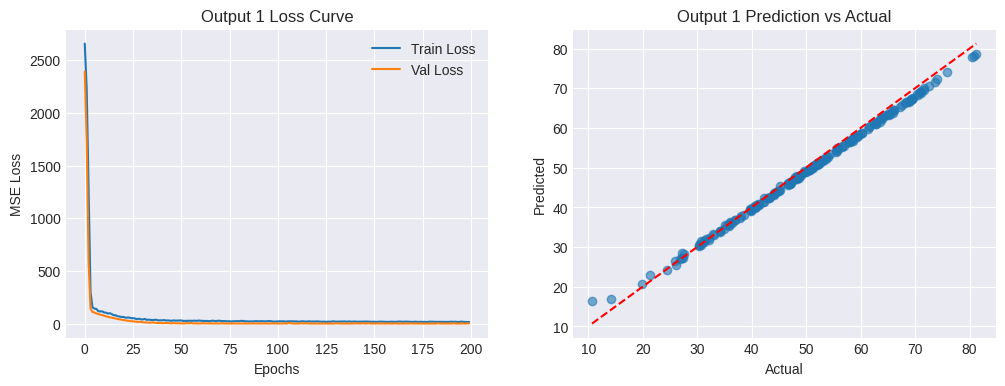

Training Output 2 Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Output 2 → R²: 0.8646, MSE: 0.2609


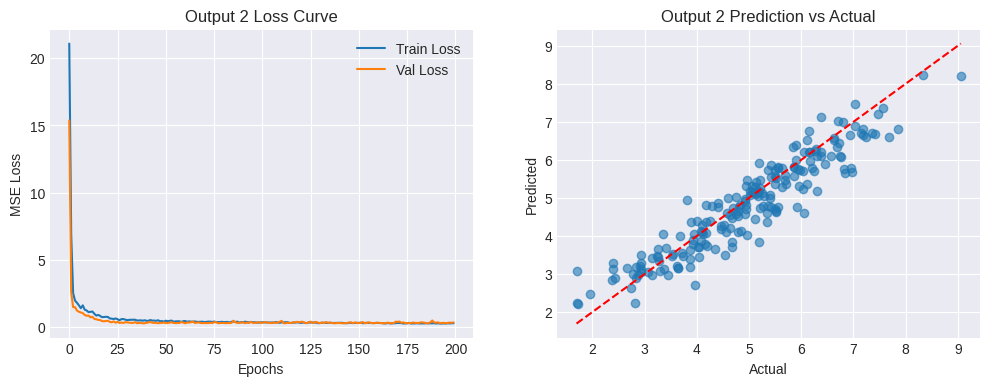

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Output 1 Evaluation ===
R² Score: 0.9910
MAE: 1.0794
MSE: 1.6624
RMSE: 1.2893
Accuracy Estimate: 99.10%
----------------------------
=== Output 2 Evaluation ===
R² Score: 0.8646
MAE: 0.3955
MSE: 0.2609
RMSE: 0.5108
Accuracy Estimate: 86.46%
----------------------------


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# === PARAMETERS ===
filename = "/content/network_performance_dataset.csv"  # change dataset for each system
epochs = 200
batch_size = 32

# === LOAD DATASET ===
df = pd.read_csv(filename)

# Separate features and outputs
X = df.iloc[:, :-2].values
y1 = df.iloc[:, -2].values  # Output 1
y2 = df.iloc[:, -1].values  # Output 2

# Train-test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN model builder
def build_ann(input_dim, output_dim=1):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(output_dim, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Train model function
def train_and_evaluate(X_train, y_train, X_test, y_test, name):
    model = build_ann(X_train.shape[1])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy (R² score)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} → R²: {r2:.4f}, MSE: {mse:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name} Prediction vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')

    plt.show()

    return model

# Train & evaluate both outputs
print("Training Output 1 Model...")
model1 = train_and_evaluate(X_train, y1_train, X_test, y1_test, "Output 1")

print("Training Output 2 Model...")
model2 = train_and_evaluate(X_train, y2_train, X_test, y2_test, "Output 2")

def evaluate_regression(y_true, y_pred, name="Output"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"=== {name} Evaluation ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy Estimate: {r2*100:.2f}%")  # Treat R² as accuracy estimate
    print("----------------------------")
    return r2

# Example usage after training:
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)

acc1 = evaluate_regression(y1_test, y1_pred, "Output 1")
acc2 = evaluate_regression(y2_test, y2_pred, "Output 2")



Training VPN Selection Priority Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
VPN Selection Priority → R²: 0.9975, MSE: 0.6555


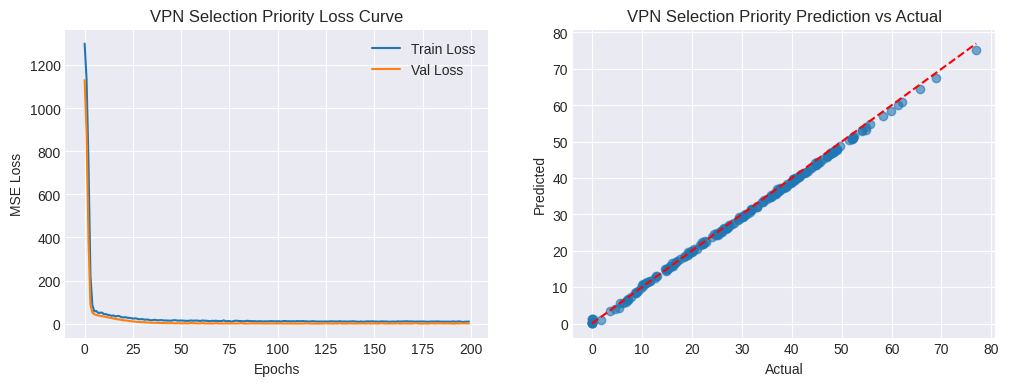

Training Connection Quality Score Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Connection Quality Score → R²: 0.9493, MSE: 0.1488


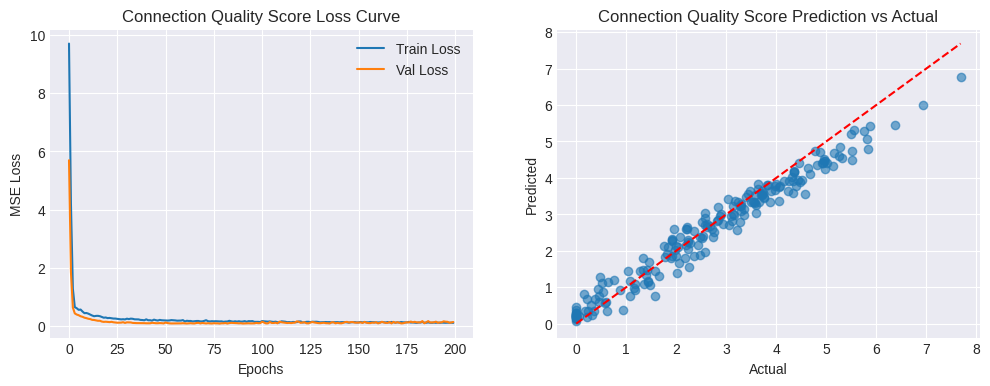

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== VPN Selection Priority Evaluation ===
R² Score: 0.9975
MAE: 0.7028
MSE: 0.6555
RMSE: 0.8097
Accuracy Estimate: 99.75%
----------------------------
=== Connection Quality Score Evaluation ===
R² Score: 0.9493
MAE: 0.3092
MSE: 0.1488
RMSE: 0.3858
Accuracy Estimate: 94.93%
----------------------------


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# === PARAMETERS ===
filename = "/content/vpn_selection_dataset.csv"  # Change to your VPN dataset
epochs = 200
batch_size = 32

# === LOAD DATASET ===
df = pd.read_csv(filename)

# Separate features and outputs
X = df.iloc[:, :-2].values
y1 = df.iloc[:, -2].values  # VPN Selection Priority
y2 = df.iloc[:, -1].values  # Connection Quality Score

# Train-test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN model builder
def build_ann(input_dim, output_dim=1):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(output_dim, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Train model function
def train_and_evaluate(X_train, y_train, X_test, y_test, name):
    model = build_ann(X_train.shape[1])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy (R² score)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} → R²: {r2:.4f}, MSE: {mse:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name} Prediction vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')

    plt.show()

    return model

# Train & evaluate both outputs
print("Training VPN Selection Priority Model...")
model1 = train_and_evaluate(X_train, y1_train, X_test, y1_test, "VPN Selection Priority")

print("Training Connection Quality Score Model...")
model2 = train_and_evaluate(X_train, y2_train, X_test, y2_test, "Connection Quality Score")

# Regression evaluation function
def evaluate_regression(y_true, y_pred, name="Output"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"=== {name} Evaluation ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy Estimate: {r2*100:.2f}%")  # Treat R² as accuracy estimate
    print("----------------------------")
    return r2

# Evaluate both outputs
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)

acc1 = evaluate_regression(y1_test, y1_pred, "VPN Selection Priority")
acc2 = evaluate_regression(y2_test, y2_pred, "Connection Quality Score")


Training Threat Level Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Threat Level → R²: 0.9908, MSE: 0.0108


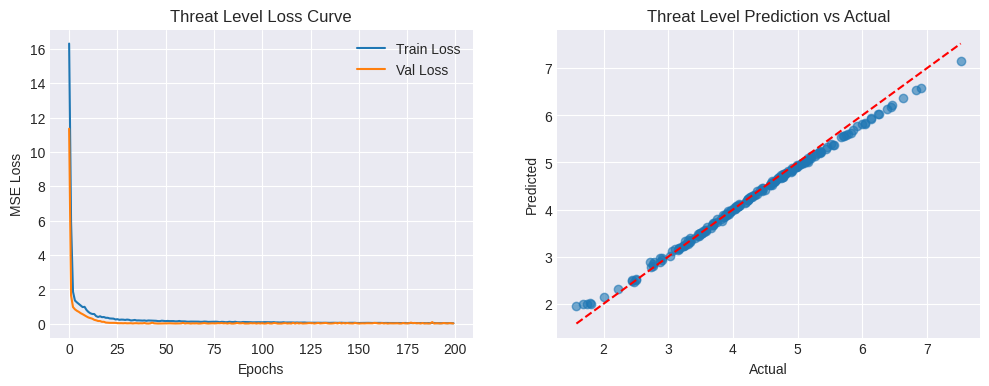

Training Response Priority Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Response Priority → R²: 0.9168, MSE: 10.0747


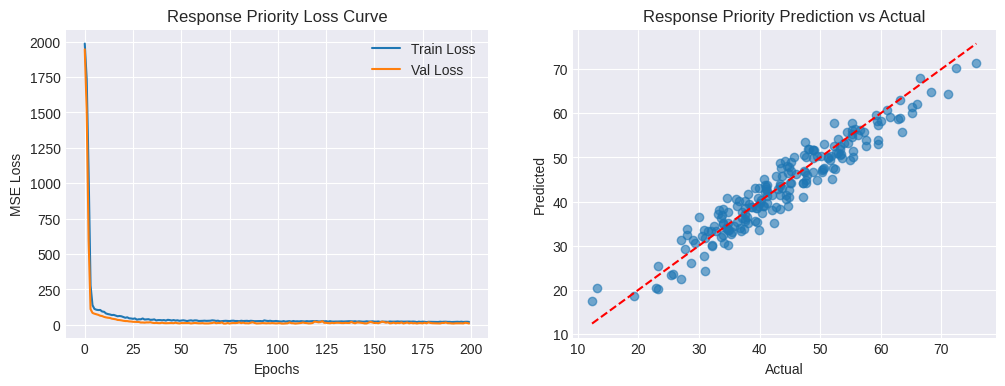

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Threat Level Evaluation ===
R² Score: 0.9908
MAE: 0.0697
MSE: 0.0108
RMSE: 0.1040
Accuracy Estimate: 99.08%
----------------------------
=== Response Priority Evaluation ===
R² Score: 0.9168
MAE: 2.6285
MSE: 10.0747
RMSE: 3.1741
Accuracy Estimate: 91.68%
----------------------------


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# === PARAMETERS ===
filename = "/content/security_threat_dataset.csv"  # Change to your Security Threat dataset
epochs = 200
batch_size = 32

# === LOAD DATASET ===
df = pd.read_csv(filename)

# Separate features and outputs
X = df.iloc[:, :-2].values
y1 = df.iloc[:, -2].values  # Threat Level
y2 = df.iloc[:, -1].values  # Response Priority

# Train-test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN model builder
def build_ann(input_dim, output_dim=1):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(output_dim, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Train model function
def train_and_evaluate(X_train, y_train, X_test, y_test, name):
    model = build_ann(X_train.shape[1])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy (R² score)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} → R²: {r2:.4f}, MSE: {mse:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name} Prediction vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')

    plt.show()

    return model

# Train & evaluate both outputs
print("Training Threat Level Model...")
model1 = train_and_evaluate(X_train, y1_train, X_test, y1_test, "Threat Level")

print("Training Response Priority Model...")
model2 = train_and_evaluate(X_train, y2_train, X_test, y2_test, "Response Priority")

# Regression evaluation function
def evaluate_regression(y_true, y_pred, name="Output"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"=== {name} Evaluation ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy Estimate: {r2*100:.2f}%")  # Treat R² as accuracy estimate
    print("----------------------------")
    return r2

# Evaluate both outputs
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)

acc1 = evaluate_regression(y1_test, y1_pred, "Threat Level")
acc2 = evaluate_regression(y2_test, y2_pred, "Response Priority")


Training Model 1 → QoS Level


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
QoS Level → R²: 0.9989, MSE: 0.1346


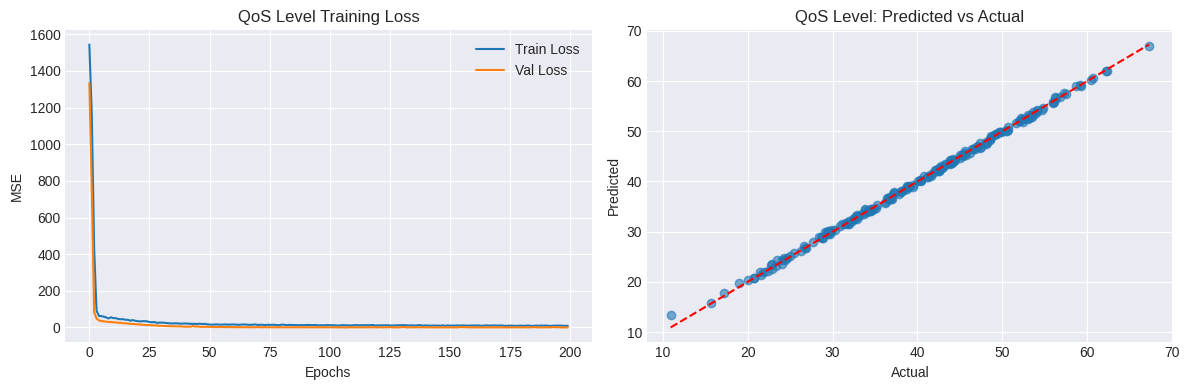


Training Model 2 → Traffic Control Action


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Traffic Control Action → R²: 0.9766, MSE: 0.0342


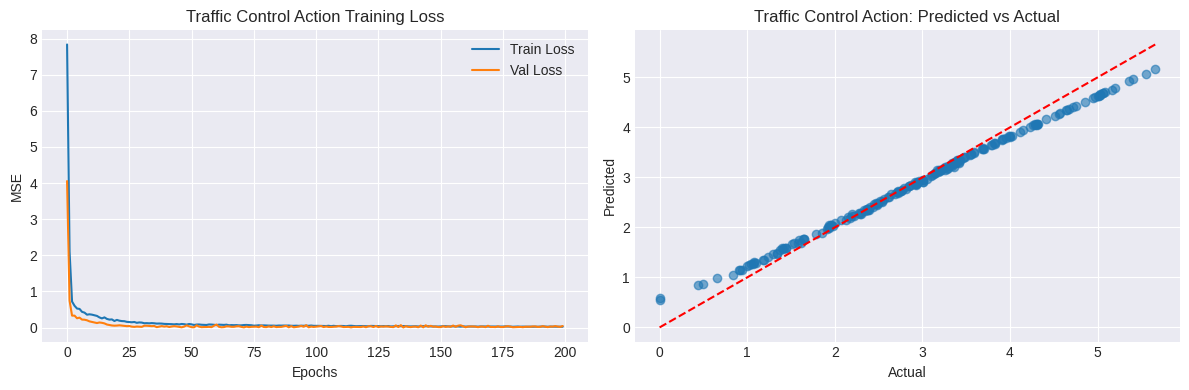

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

=== QoS Level Evaluation ===
R² Score: 0.9989
MAE: 0.2698
MSE: 0.1346
RMSE: 0.3669
Accuracy Estimate: 99.89%
----------------------------

=== Traffic Control Action Evaluation ===
R² Score: 0.9766
MAE: 0.1373
MSE: 0.0342
RMSE: 0.1849
Accuracy Estimate: 97.66%
----------------------------

 Overall System Accuracy ≈ 98.77%


In [28]:
# === IP & QoS Optimization ANN ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# === PARAMETERS ===
filename = "/content/ip_qos_optimizer_dataset.csv"   # <-- your dataset file
epochs = 200
batch_size = 32

# === LOAD DATASET ===
df = pd.read_csv(filename)

# Last two columns are outputs: QoS_Level and Traffic_Control_Action
X = df.iloc[:, :-2].values
y1 = df.iloc[:, -2].values  # QoS Level
y2 = df.iloc[:, -1].values  # Traffic Control Action

# Train-test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === ANN MODEL BUILDER ===
def build_ann(input_dim, output_dim=1):
    model = Sequential([
        Dense(128, input_dim=input_dim, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='linear')  # Regression outputs
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# === TRAINING FUNCTION ===
def train_and_evaluate(X_train, y_train, X_test, y_test, name):
    model = build_ann(X_train.shape[1])
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_split=0.2,
                        verbose=0)

    # Predictions
    y_pred = model.predict(X_test)

    # Performance
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} → R²: {r2:.4f}, MSE: {mse:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name}: Predicted vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()

    return model

# === TRAINING BOTH MODELS ===
print("Training Model 1 → QoS Level")
model1 = train_and_evaluate(X_train, y1_train, X_test, y1_test, "QoS Level")

print("\nTraining Model 2 → Traffic Control Action")
model2 = train_and_evaluate(X_train, y2_train, X_test, y2_test, "Traffic Control Action")

# === REGRESSION EVALUATION FUNCTION ===
def evaluate_regression(y_true, y_pred, name="Output"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n=== {name} Evaluation ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy Estimate: {r2 * 100:.2f}%")
    print("----------------------------")
    return r2

# === FINAL EVALUATION ===
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)

acc1 = evaluate_regression(y1_test, y1_pred, "QoS Level")
acc2 = evaluate_regression(y2_test, y2_pred, "Traffic Control Action")

print(f"\n Overall System Accuracy ≈ {(acc1 + acc2) / 2 * 100:.2f}%")


✅ Loaded uploaded dataset.
   Network_Latency  Bandwidth_Utilisation  Packet_Loss_Rate   CPU_Usage  \
0        87.263185              65.268755          2.354258  100.000000   
1        27.171702              57.141595          2.752675   68.288232   
2        69.296729              64.545778          1.174133   23.880838   
3        58.158624              20.327318          0.154918   62.488305   
4        52.290485              91.106765          0.418291    0.000000   

   Memory_Usage  Network_Performance_Index  Optimization_Priority  
0     19.051352                  32.067334               6.790289  
1     40.083610                  55.768071               3.848485  
2     48.148971                  51.722272               5.674765  
3    100.000000                  54.740545               4.981527  
4     30.103266                  57.898401               4.487485  
Generation 10/80 | Best NPI: 93.72, Priority: 1.04
Generation 20/80 | Best NPI: 98.22, Priority: 0.21
Generation 3

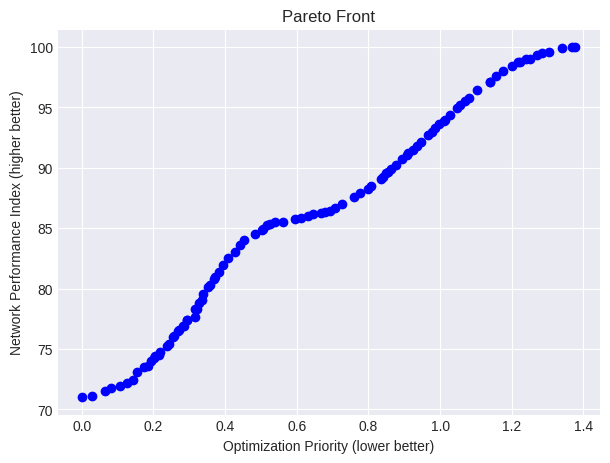

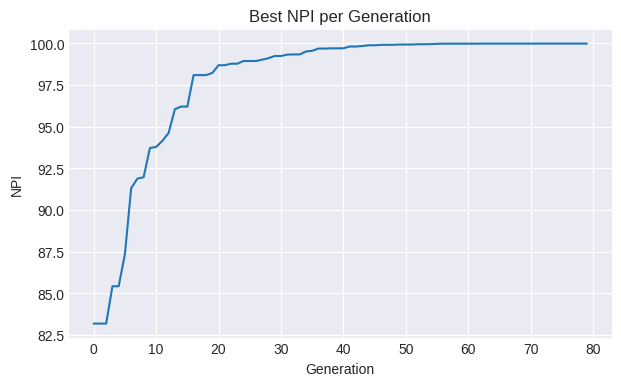

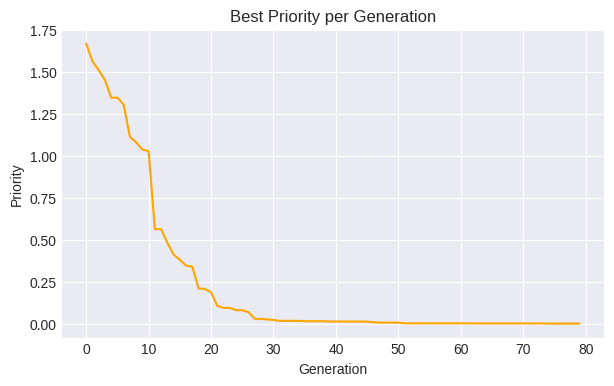

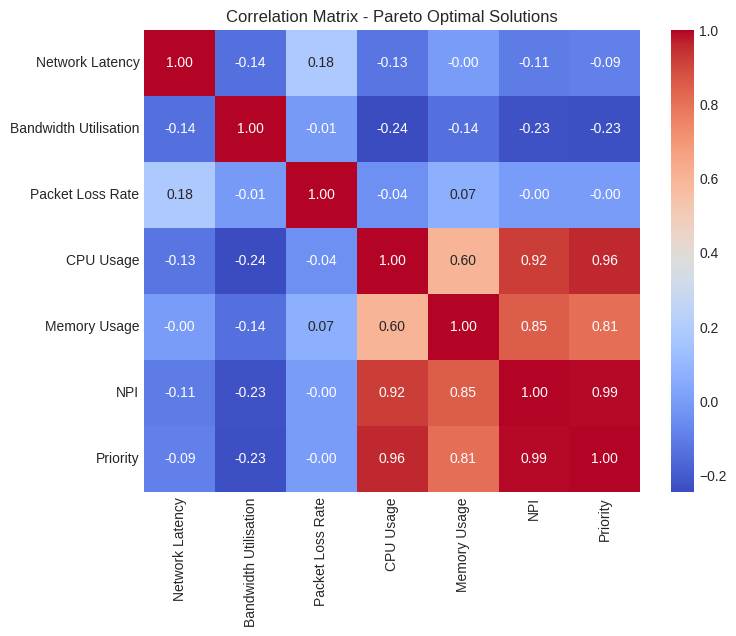

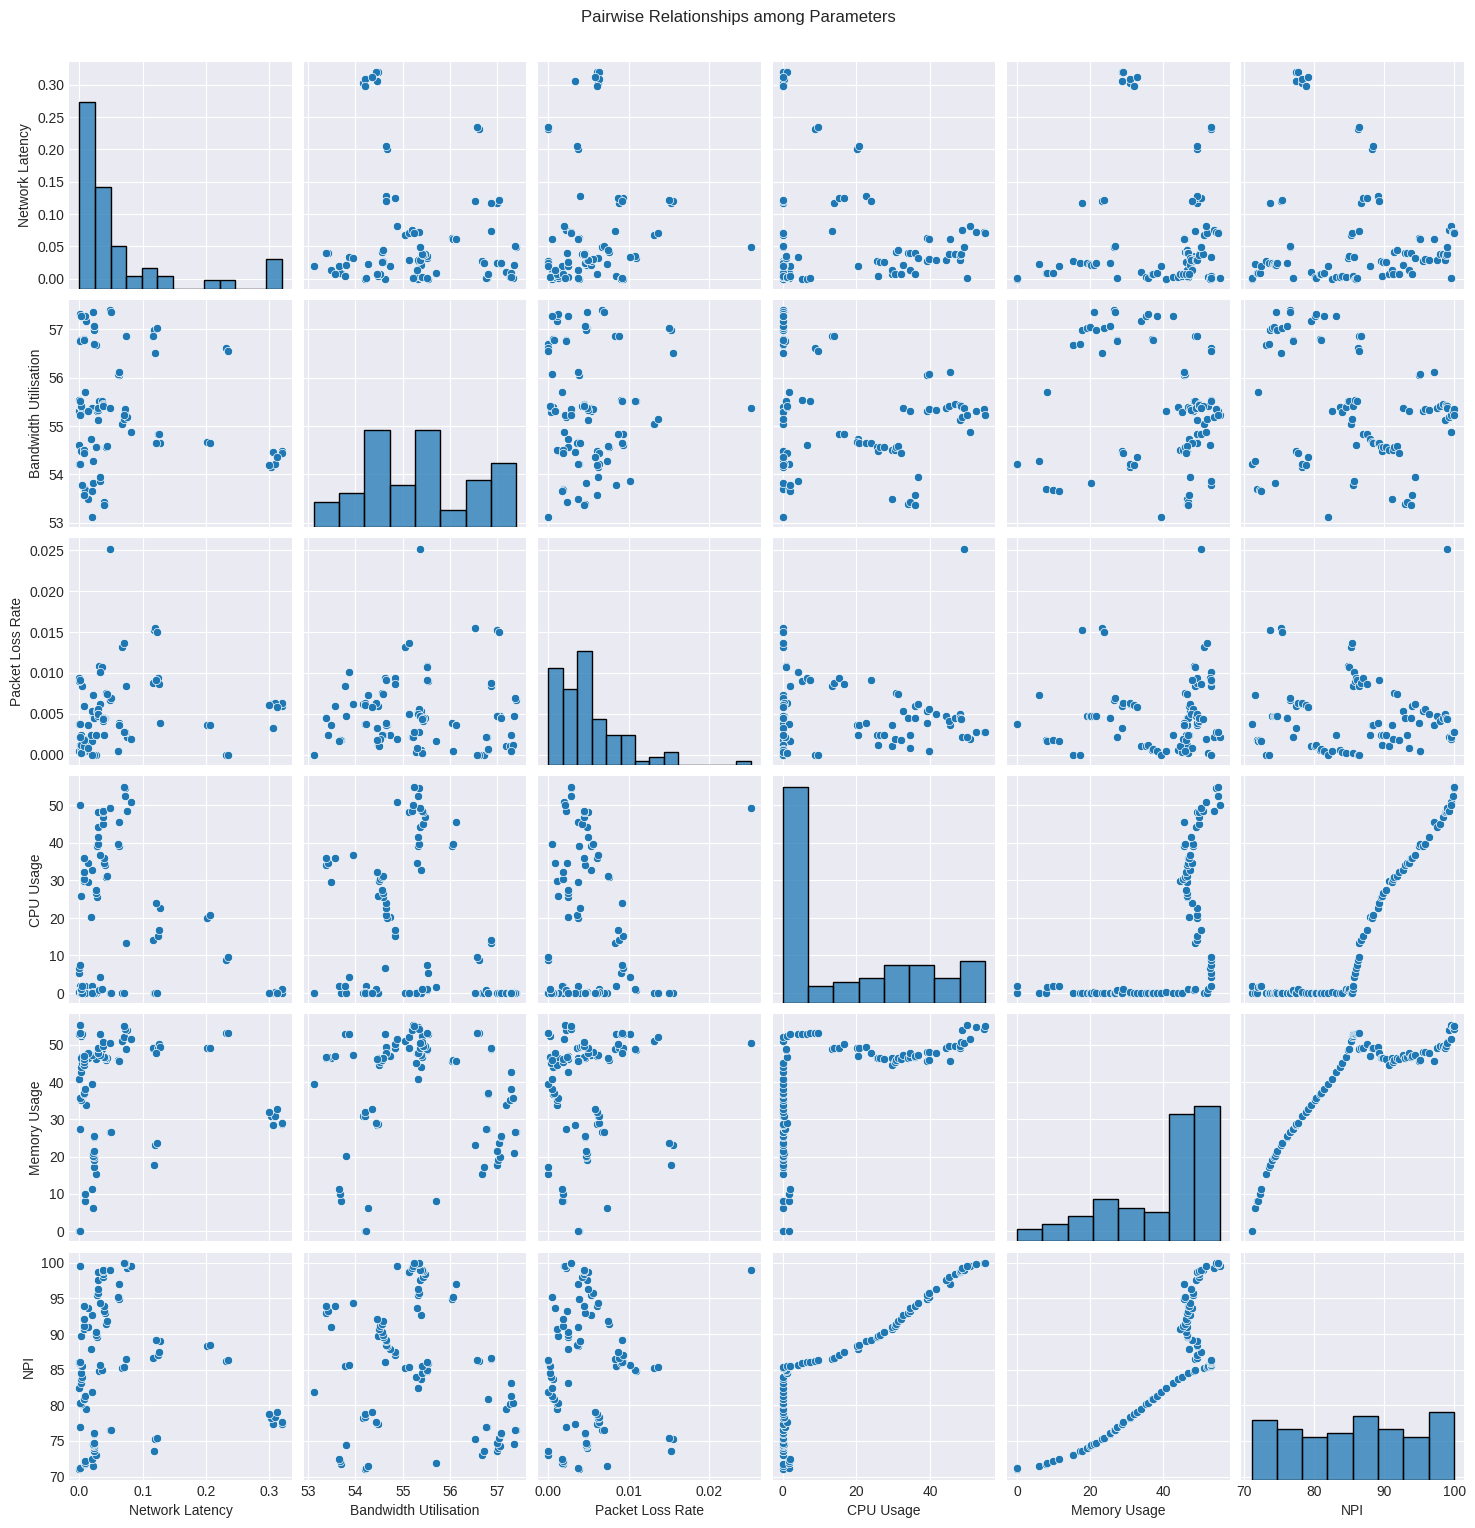

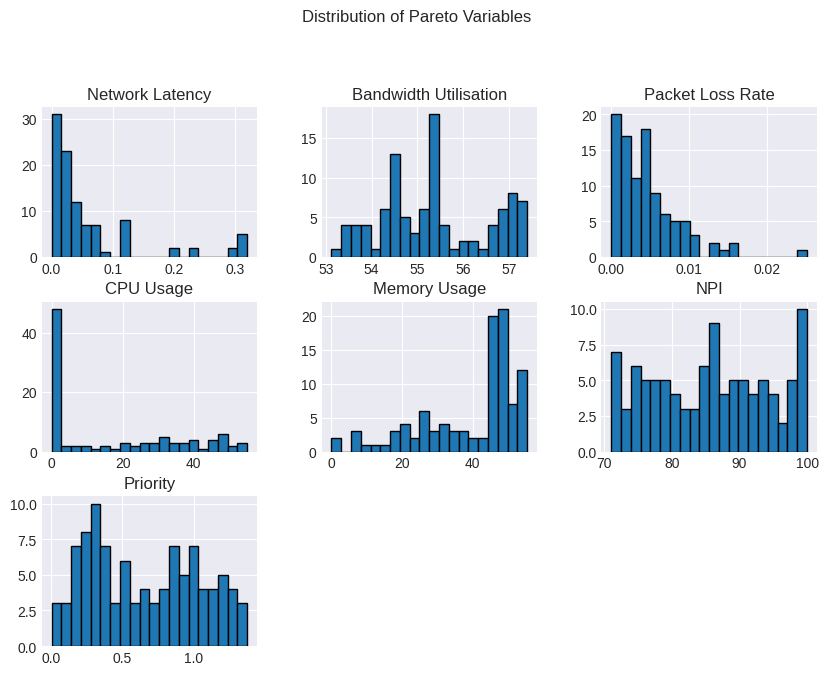

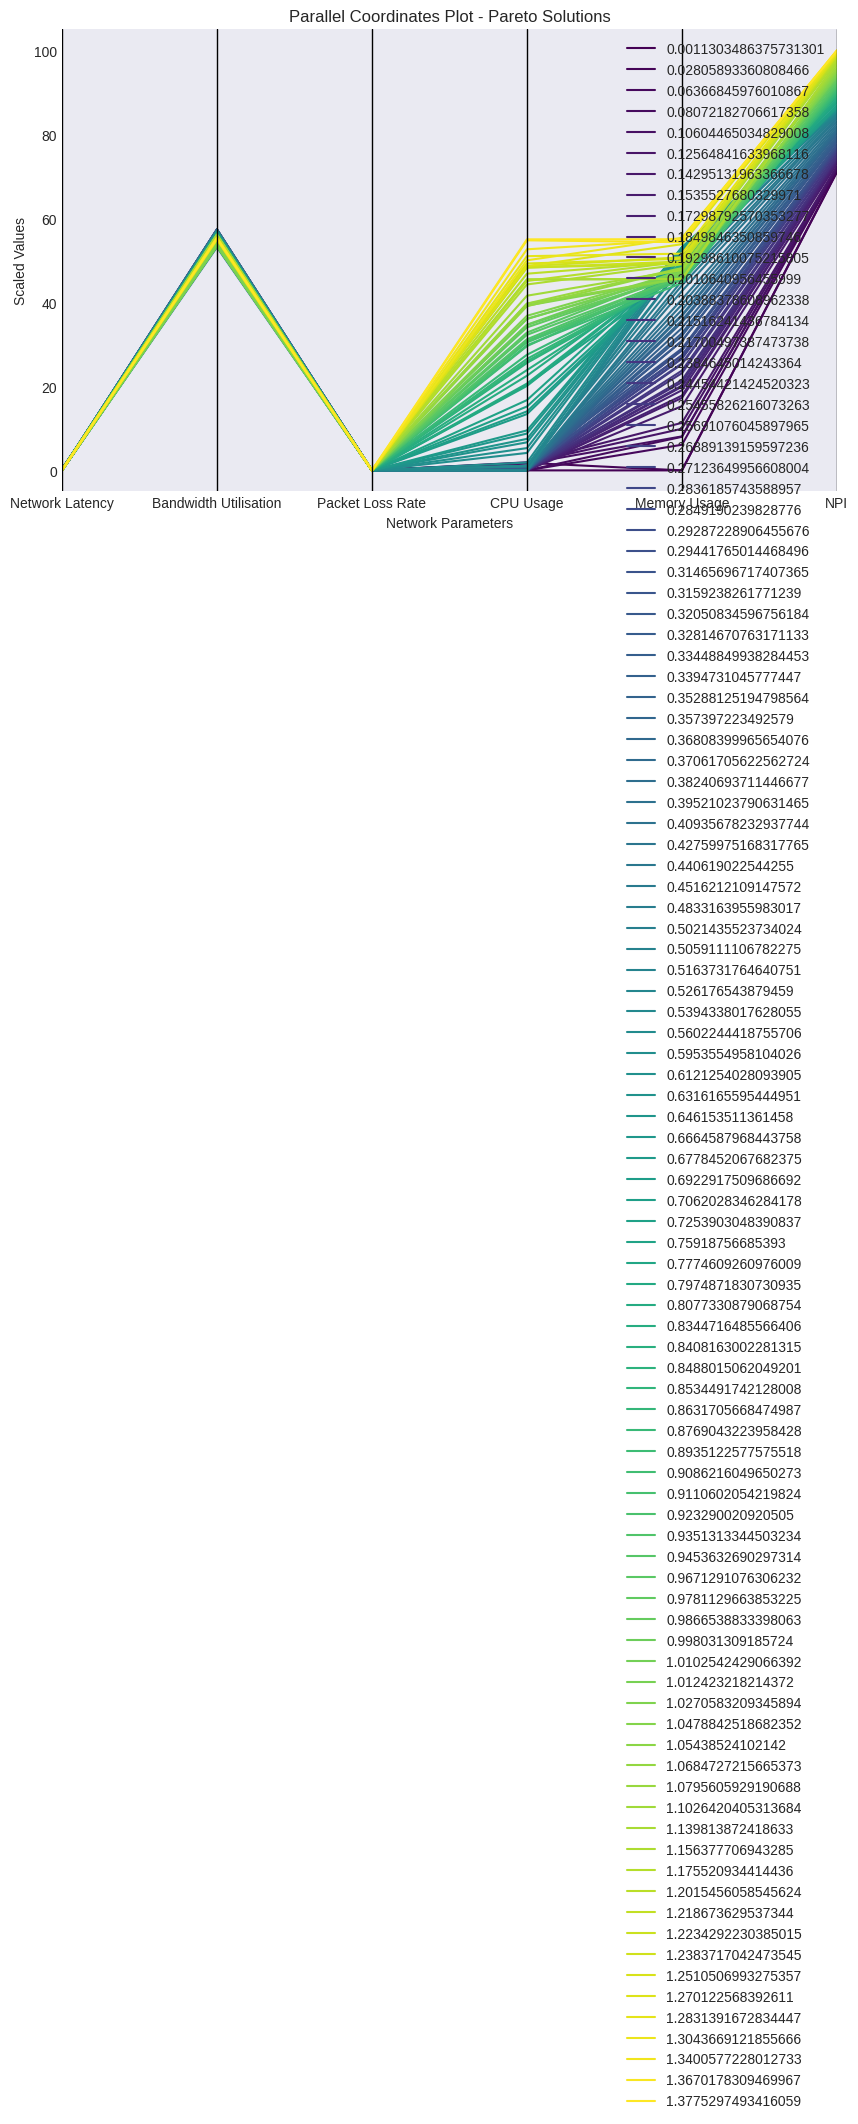

In [29]:
# ======================================
# Multiobjective Genetic Algorithm (NSGA-II)
# with Visualization and Analytics
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------
# 1. DATA LOADING OR GENERATION
# -----------------------------
np.random.seed(42)

# Define input parameter ranges
ranges = {
    'Network Latency': (0, 200),
    'Bandwidth Utilisation': (0, 100),
    'Packet Loss Rate': (0, 10),
    'CPU Usage': (0, 100),
    'Memory Usage': (0, 100)
}

csv_path = '/content/network_performance_dataset.csv'

def generate_synthetic(n=1000):
    data = {}
    for k, (lo, hi) in ranges.items():
        data[k] = np.random.uniform(lo, hi, size=n)
    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False)
    return df

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("✅ Loaded uploaded dataset.")
else:
    df = generate_synthetic(1000)
    print("⚙️ Generated synthetic dataset (dataset.csv)")

print(df.head())

# -----------------------------
# 2. OBJECTIVE FUNCTIONS
# -----------------------------
def compute_npi(row):
    latency = row['Network Latency']
    bw = row['Bandwidth Utilisation']
    pl = row['Packet Loss Rate']
    cpu = row['CPU Usage']
    mem = row['Memory Usage']

    s_latency = max(0, 1 - latency / 200)
    s_pl = max(0, 1 - pl / 10)
    s_bw = np.exp(-((bw - 55) / 25) ** 2)
    s_cpu = np.exp(-((cpu - 55) / 30) ** 2)
    s_mem = np.exp(-((mem - 55) / 30) ** 2)

    weights = np.array([0.30, 0.25, 0.15, 0.15, 0.15])
    comps = np.array([s_latency, s_pl, s_bw, s_cpu, s_mem])
    score = np.dot(weights, comps)
    return float(score * 100)

def compute_priority(row):
    latency = row['Network Latency']
    bw = row['Bandwidth Utilisation']
    pl = row['Packet Loss Rate']
    cpu = row['CPU Usage']
    mem = row['Memory Usage']

    p_latency = latency / 200
    p_pl = pl / 10
    p_cpu = cpu / 100
    p_mem = mem / 100
    p_bw = max(0, (bw - 80) / 20)

    raw = 0.4*p_latency + 0.3*p_pl + 0.15*p_cpu + 0.1*p_mem + 0.05*p_bw
    return float(raw * 10)

# -----------------------------
# 3. NSGA-II SETUP
# -----------------------------
var_names = list(ranges.keys())
num_vars = len(var_names)
lower = np.array([ranges[k][0] for k in var_names])
upper = np.array([ranges[k][1] for k in var_names])

pop_size = 100
gens = 80

def evaluate(ind):
    row = {name: ind[i] for i, name in enumerate(var_names)}
    npi = compute_npi(row)
    pr = compute_priority(row)
    return (-npi, pr)  # minimize both

# SBX crossover
def sbx_crossover(p1, p2, eta=15):
    u = np.random.rand(len(p1))
    beta = np.where(u <= 0.5, (2*u)**(1/(eta+1)), (1/(2*(1-u)))**(1/(eta+1)))
    c1 = 0.5*((1+beta)*p1 + (1-beta)*p2)
    c2 = 0.5*((1-beta)*p1 + (1+beta)*p2)
    return np.clip(c1, lower, upper), np.clip(c2, lower, upper)

# Polynomial mutation
def poly_mutation(child, eta=20, pm=0.1):
    for i in range(len(child)):
        if np.random.rand() < pm:
            x, xl, xu = child[i], lower[i], upper[i]
            r = np.random.rand()
            delta1 = (x - xl) / (xu - xl)
            delta2 = (xu - x) / (xu - xl)
            mut_pow = 1.0 / (eta + 1.0)
            if r < 0.5:
                xy = 1.0 - delta1
                val = 2.0*r + (1.0 - 2.0*r)*(xy**(eta+1))
                deltaq = val**mut_pow - 1.0
            else:
                xy = 1.0 - delta2
                val = 2.0*(1.0 - r) + 2.0*(r - 0.5)*(xy**(eta+1))
                deltaq = 1.0 - val**mut_pow
            x = x + deltaq*(xu - xl)
            child[i] = np.clip(x, xl, xu)
    return child

# Non-dominated sorting
def nondominated_sort(objs):
    S = [[] for _ in objs]
    n = [0]*len(objs)
    front = [[]]
    for p in range(len(objs)):
        for q in range(len(objs)):
            if all(objs[p] <= objs[q]) and any(objs[p] < objs[q]):
                S[p].append(q)
            elif all(objs[q] <= objs[p]) and any(objs[q] < objs[p]):
                n[p] += 1
        if n[p] == 0:
            front[0].append(p)
    i = 0
    while front[i]:
        Q = []
        for p in front[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    Q.append(q)
        i += 1
        front.append(Q)
    front.pop()
    return front

# Crowding distance
def crowding_distance(front, objs):
    l = len(front)
    if l == 0: return []
    dist = np.zeros(l)
    for m in range(objs.shape[1]):
        vals = objs[front, m]
        sorted_idx = np.argsort(vals)
        dist[sorted_idx[0]] = dist[sorted_idx[-1]] = np.inf
        if vals[sorted_idx[-1]] == vals[sorted_idx[0]]:
            continue
        for i in range(1, l-1):
            dist[sorted_idx[i]] += (vals[sorted_idx[i+1]] - vals[sorted_idx[i-1]]) / \
                                   (vals[sorted_idx[-1]] - vals[sorted_idx[0]])
    return dist

# -----------------------------
# 4. MAIN NSGA-II LOOP
# -----------------------------
pop = [np.random.uniform(lower, upper) for _ in range(pop_size)]
pop_objs = np.array([evaluate(ind) for ind in pop])

best_npi, best_pr = [], []

for g in range(gens):
    fronts = nondominated_sort(pop_objs)
    ranks = np.zeros(len(pop), dtype=int)
    for i, f in enumerate(fronts):
        for idx in f:
            ranks[idx] = i
    cd = np.zeros(len(pop))
    for f in fronts:
        d = crowding_distance(f, pop_objs)
        for i, idx in enumerate(f):
            cd[idx] = d[i]

    offspring = []
    while len(offspring) < pop_size:
        a, b = np.random.choice(len(pop), 2, replace=False)
        winner = a if (ranks[a] < ranks[b] or (ranks[a]==ranks[b] and cd[a]>cd[b])) else b
        offspring.append(pop[winner].copy())

    children = []
    for i in range(0, pop_size, 2):
        if i+1 < pop_size and np.random.rand() < 0.9:
            c1, c2 = sbx_crossover(offspring[i], offspring[i+1])
        else:
            c1, c2 = offspring[i], offspring[i+1]
        children.append(poly_mutation(c1.copy()))
        children.append(poly_mutation(c2.copy()))
    children = children[:pop_size]

    combined = pop + children
    combined_objs = np.array([evaluate(ind) for ind in combined])
    fronts = nondominated_sort(combined_objs)

    new_pop, new_objs = [], []
    for f in fronts:
        if len(new_pop) + len(f) > pop_size:
            d = crowding_distance(f, combined_objs)
            idx_sorted = np.argsort(-d)
            for idx in idx_sorted:
                if len(new_pop) >= pop_size: break
                new_pop.append(combined[f[idx]])
                new_objs.append(combined_objs[f[idx]])
            break
        else:
            for idx in f:
                new_pop.append(combined[idx])
                new_objs.append(combined_objs[idx])

    pop, pop_objs = new_pop, np.array(new_objs)
    best_npi.append(-np.min(pop_objs[:, 0]))
    best_pr.append(np.min(pop_objs[:, 1]))

    if (g+1) % 10 == 0:
        print(f"Generation {g+1}/{gens} | Best NPI: {best_npi[-1]:.2f}, Priority: {best_pr[-1]:.2f}")

# -----------------------------
# 5. RESULTS AND VISUALIZATION
# -----------------------------
final_fronts = nondominated_sort(pop_objs)
pareto_idx = final_fronts[0]
pareto = []
for idx in pareto_idx:
    ind = pop[idx]
    npi = -pop_objs[idx, 0]
    pr = pop_objs[idx, 1]
    row = {name: ind[i] for i, name in enumerate(var_names)}
    row.update({'NPI': npi, 'Priority': pr})
    pareto.append(row)
pareto_df = pd.DataFrame(pareto).sort_values(by='Priority')

pareto_df.to_csv("pareto_solutions.csv", index=False)
print("\n Pareto solutions saved to pareto_solutions.csv")

# --- Basic Pareto Front ---
plt.figure(figsize=(7,5))
plt.scatter(pareto_df['Priority'], pareto_df['NPI'], color='blue')
plt.xlabel("Optimization Priority (lower better)")
plt.ylabel("Network Performance Index (higher better)")
plt.title("Pareto Front")
plt.grid(True)
plt.show()

# --- Performance over Generations ---
plt.figure(figsize=(7,4))
plt.plot(best_npi, label='Best NPI')
plt.xlabel("Generation")
plt.ylabel("NPI")
plt.title("Best NPI per Generation")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(best_pr, label='Best Priority', color='orange')
plt.xlabel("Generation")
plt.ylabel("Priority")
plt.title("Best Priority per Generation")
plt.grid(True)
plt.show()

# -----------------------------
# 6. ADDITIONAL VISUAL ANALYTICS
# -----------------------------
# Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(pareto_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Pareto Optimal Solutions")
plt.show()

# Pairplot (visual relationship among variables)
sns.pairplot(pareto_df, vars=['Network Latency','Bandwidth Utilisation','Packet Loss Rate','CPU Usage','Memory Usage','NPI'], hue=None)
plt.suptitle("Pairwise Relationships among Parameters", y=1.02)
plt.show()

# Histograms for each variable
pareto_df.hist(bins=20, figsize=(10,7), edgecolor='black')
plt.suptitle("Distribution of Pareto Variables", y=1.02)
plt.show()

# Parallel Coordinates Plot for Pareto solutions
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(10,6))
parallel_coordinates(pareto_df[['Network Latency','Bandwidth Utilisation','Packet Loss Rate','CPU Usage','Memory Usage','NPI','Priority']],
                     class_column='Priority', colormap=plt.cm.viridis)
plt.title("Parallel Coordinates Plot - Pareto Solutions")
plt.xlabel("Network Parameters")
plt.ylabel("Scaled Values")
plt.show()


Best Binary Solution: [0 0 0 0 0 1]
Selected Feature Indices: [5]
Best Fitness: 0.9435982348180072


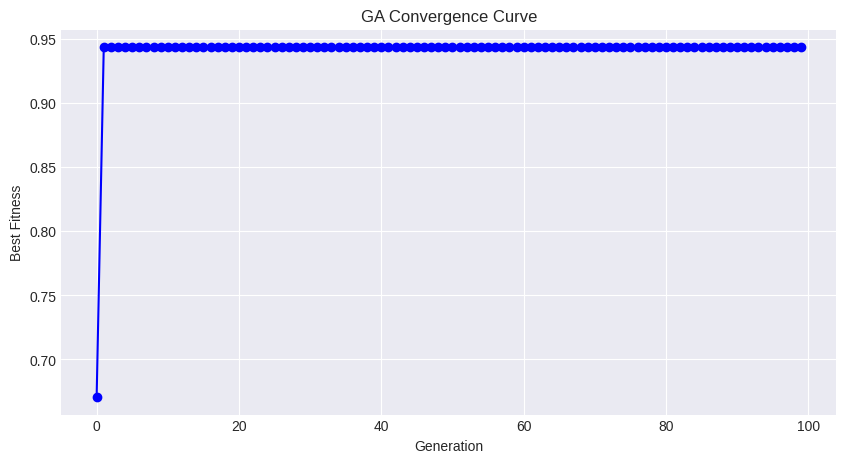

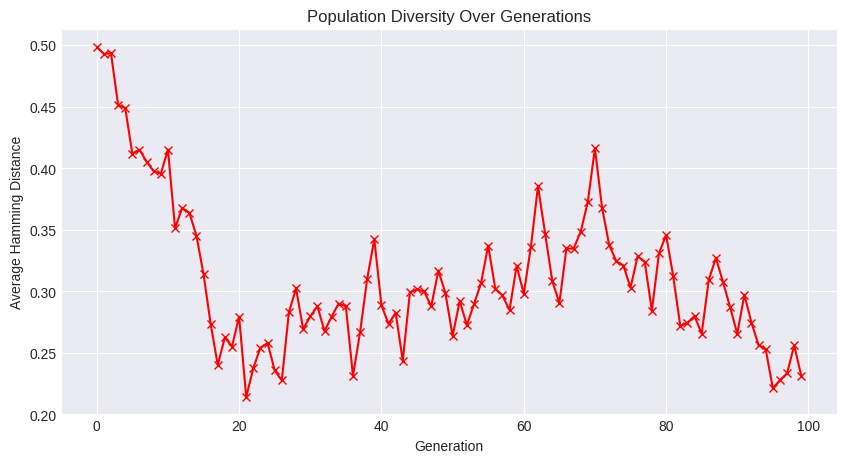

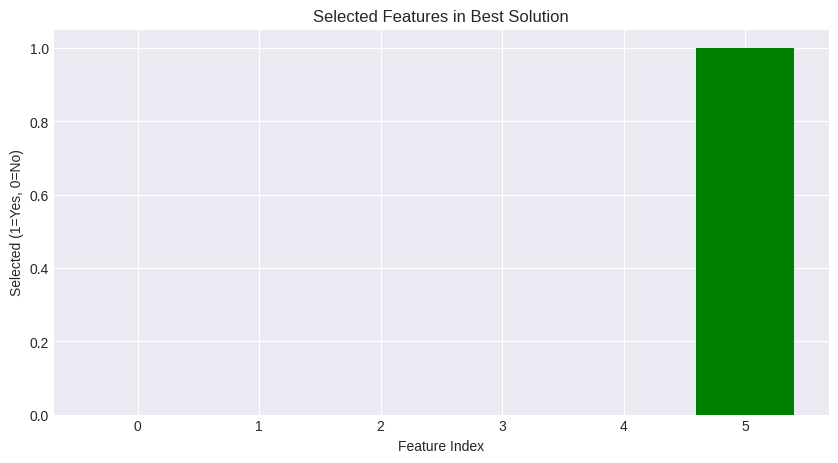

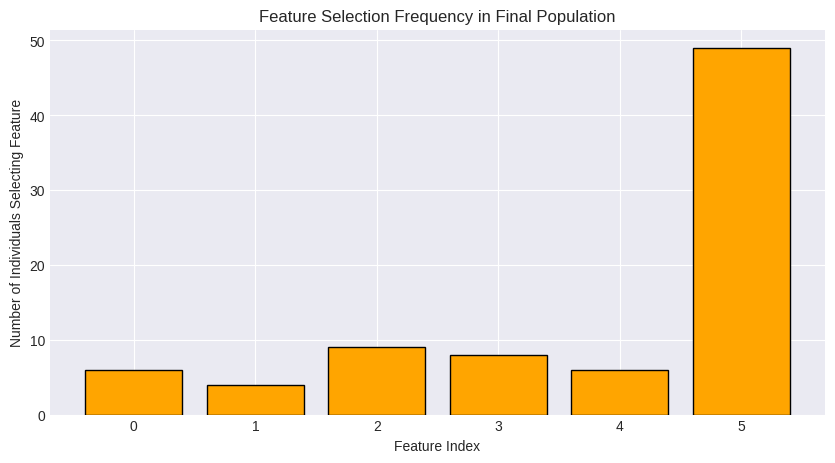

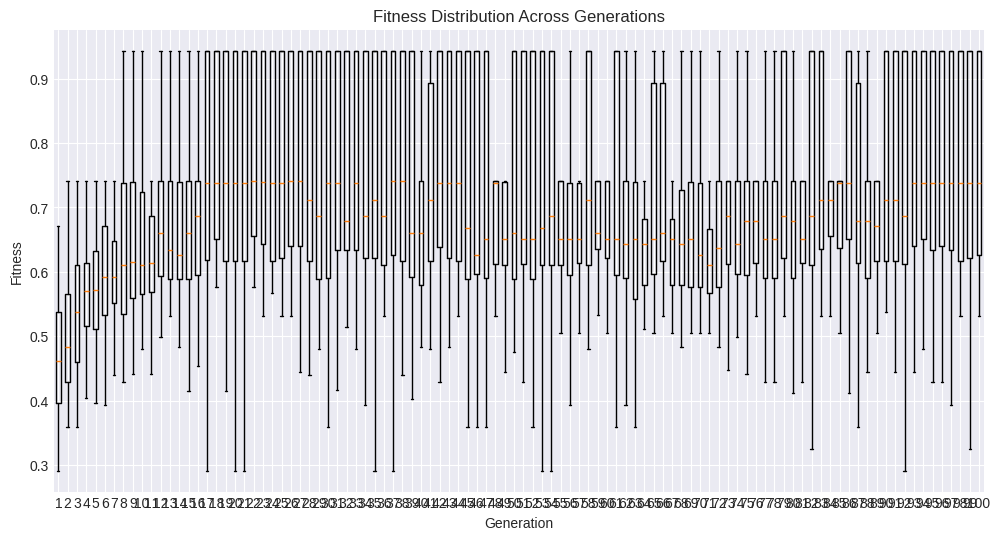

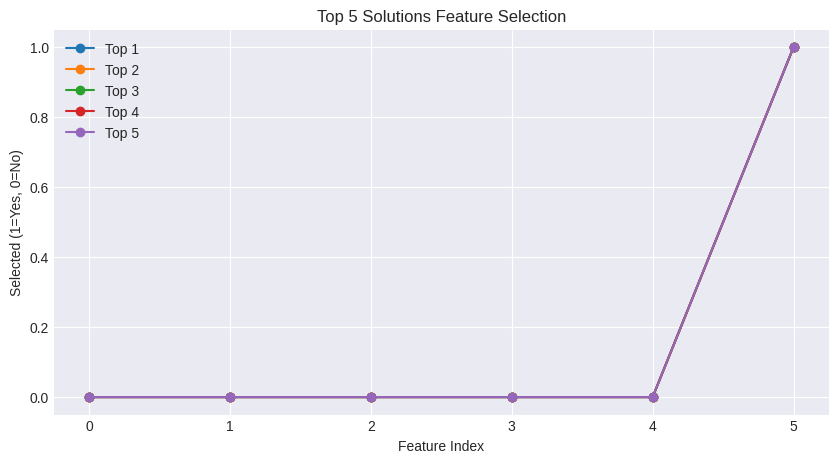

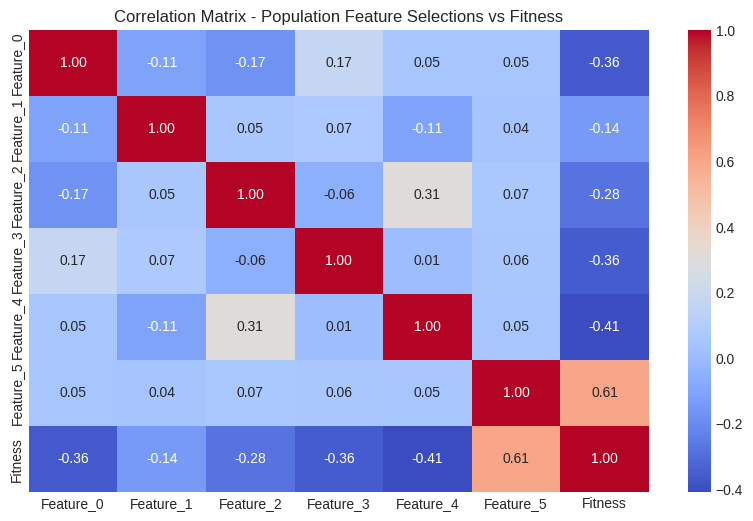

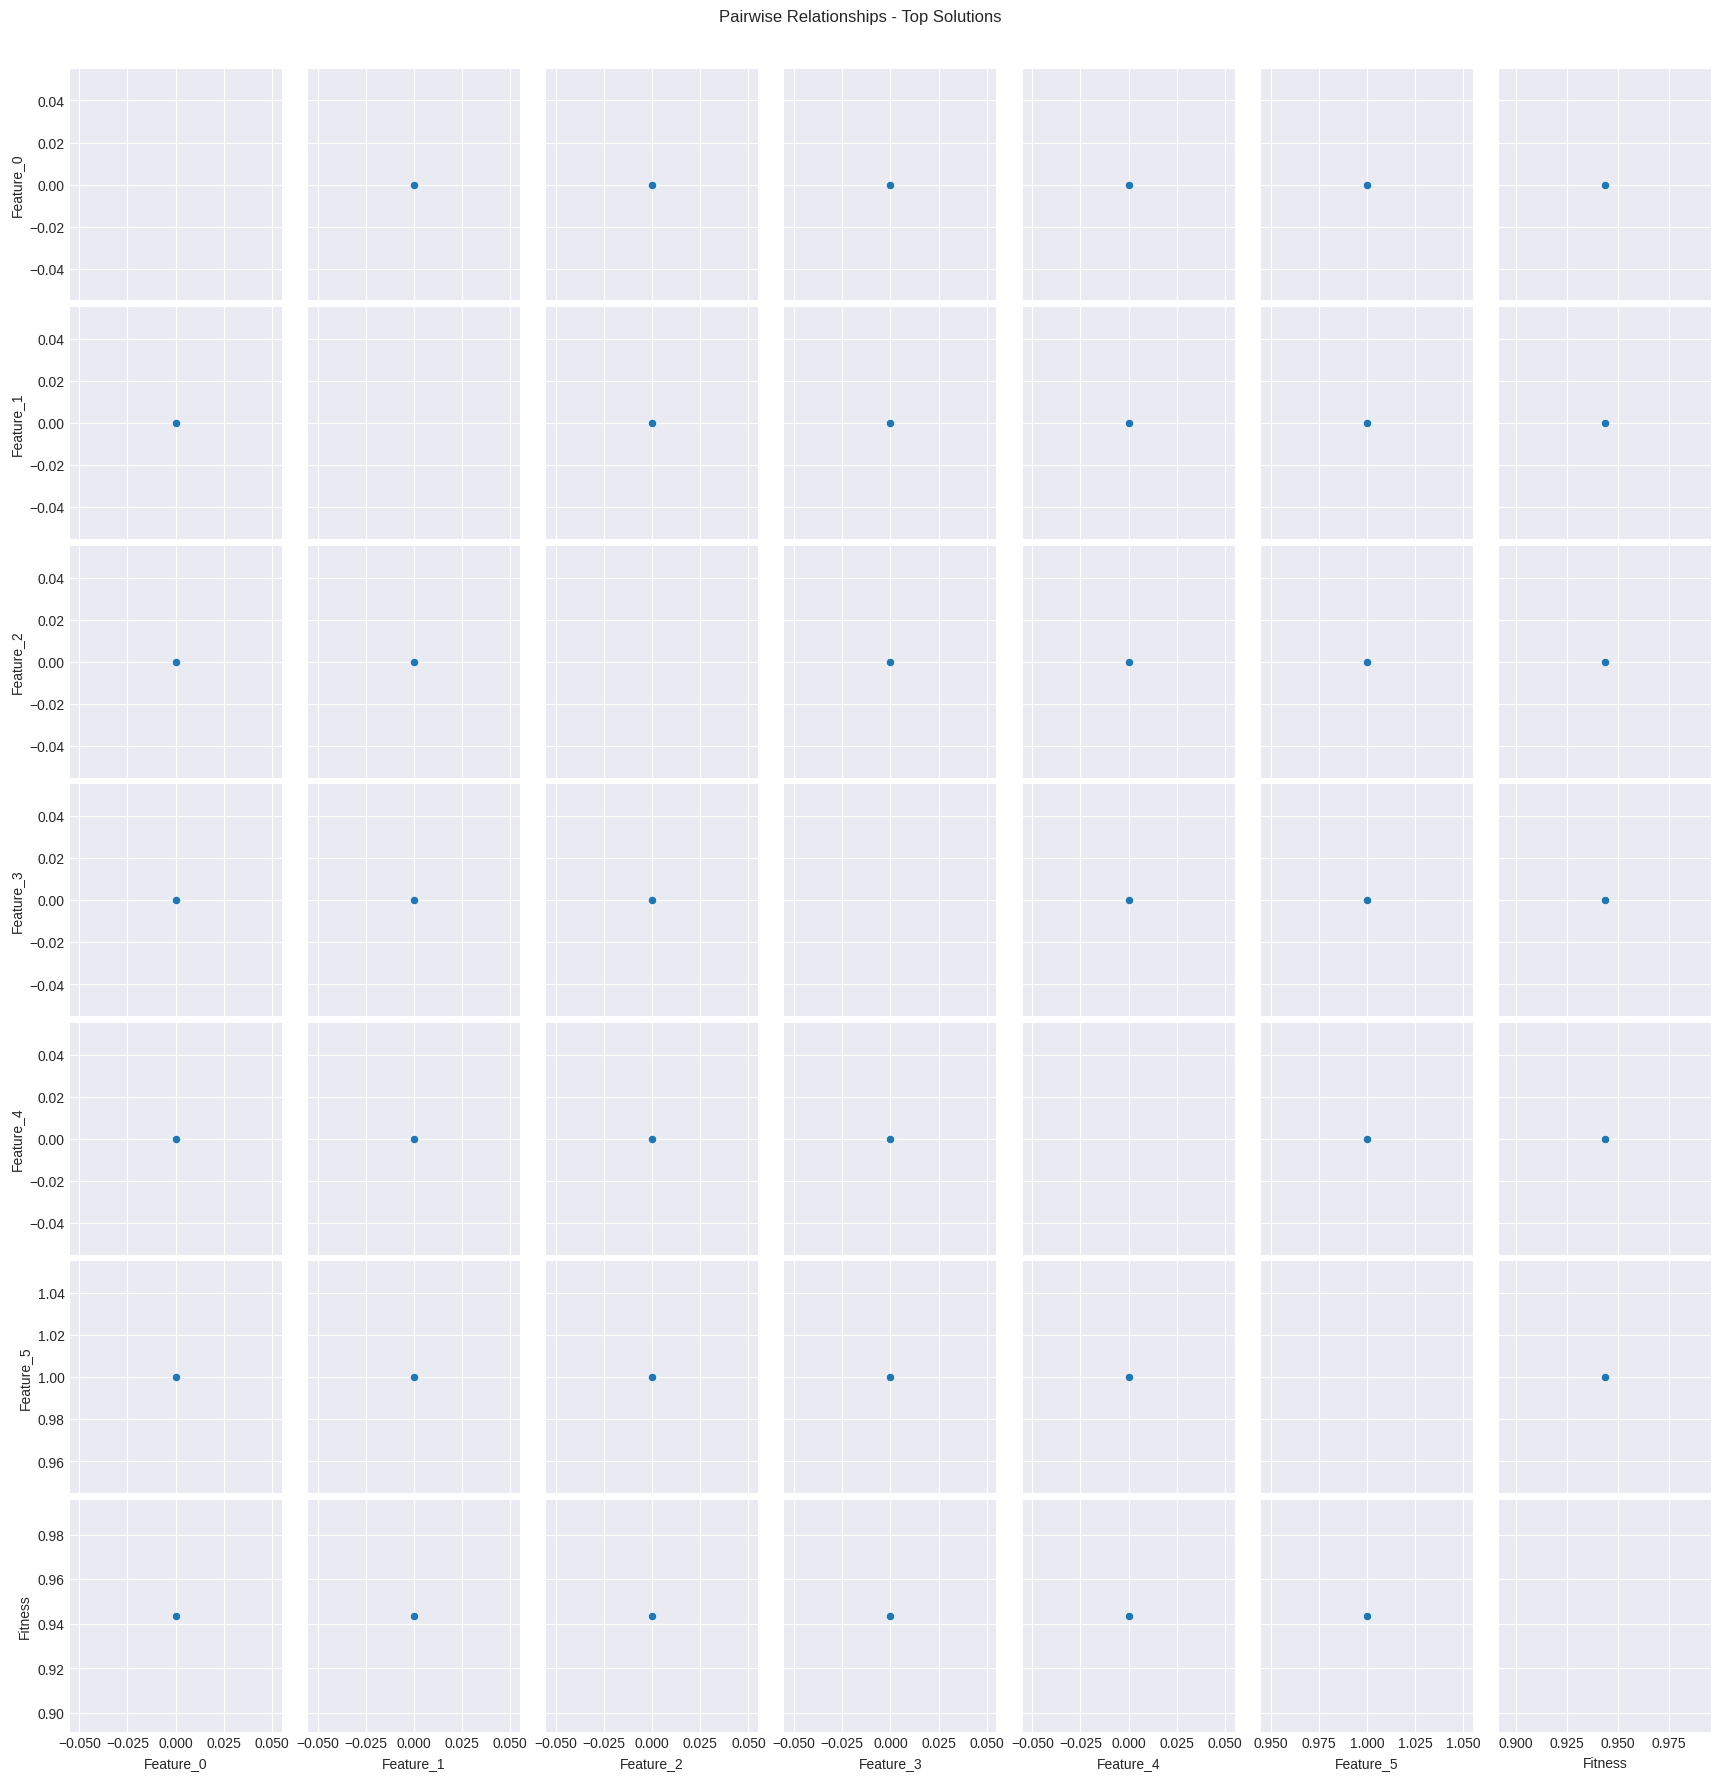

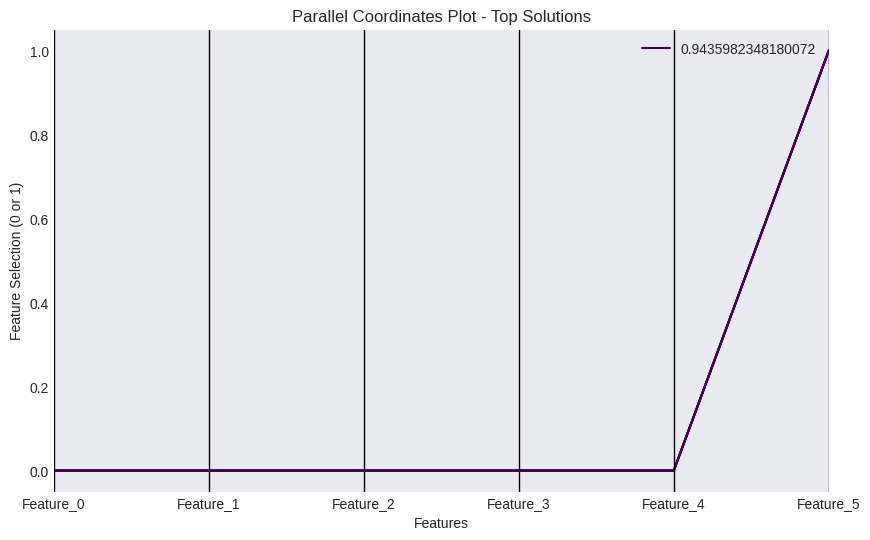

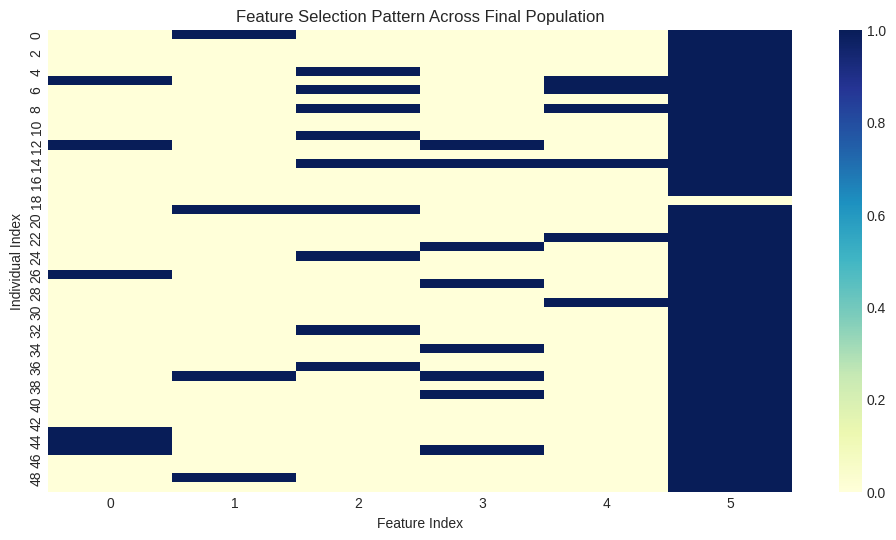

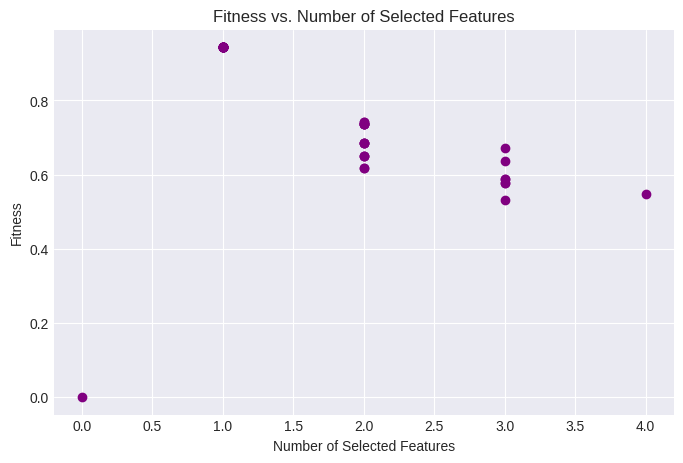

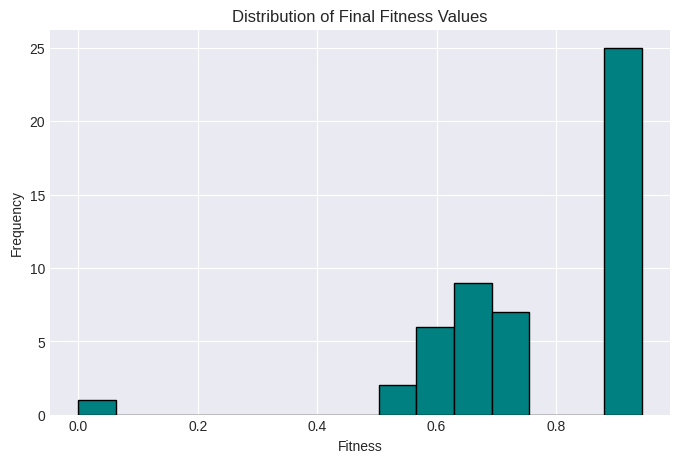

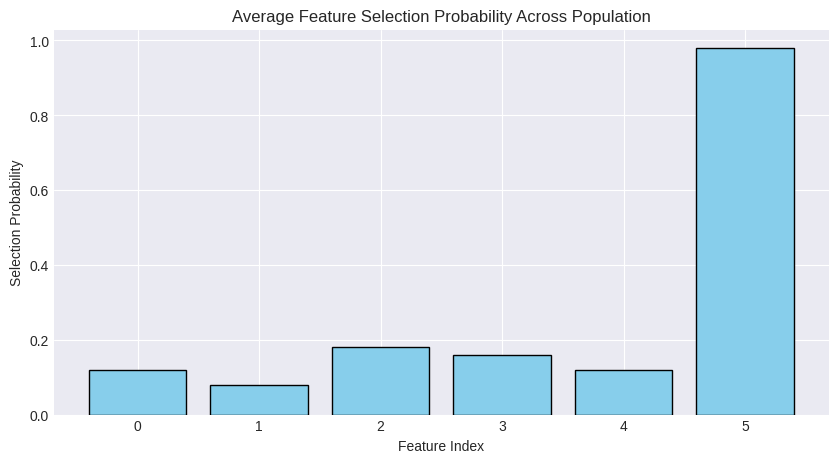

 Saved detailed analytics: vpn_feature_selection_top_solutions.csv


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# ==============================
# User Input: Dataset Path
# ==============================
dataset_path = "/content/vpn_selection_dataset.csv"  # <-- replace with your dataset path
data = pd.read_csv(dataset_path)

# ==============================
# GA Parameters
# ==============================
POP_SIZE = 50
NUM_GEN = 100
MUTATION_RATE = 0.05
ELITISM = True

NUM_FEATURES = data.shape[1] - 1  # last column as target
CHROMOSOME_LENGTH = NUM_FEATURES

# ==============================
# Fitness Function
# ==============================
def fitness(chromosome, data):
    selected_features = [i for i, gene in enumerate(chromosome) if gene == 1]
    if not selected_features:
        return 0
    X = data.iloc[:, selected_features]
    y = data.iloc[:, -1]
    # Mean absolute correlation with target
    corr = np.mean([abs(np.corrcoef(X.iloc[:, i], y)[0, 1]) for i in range(X.shape[1])])
    return corr

# ==============================
# GA Operators
# ==============================
def initialize_population():
    return np.random.randint(2, size=(POP_SIZE, CHROMOSOME_LENGTH))

def select_parents(pop, fitnesses):
    total_fit = sum(fitnesses)
    probs = [f / total_fit if total_fit > 0 else 1/POP_SIZE for f in fitnesses]
    parents_idx = np.random.choice(range(POP_SIZE), size=2, p=probs)
    return pop[parents_idx[0]], pop[parents_idx[1]]

def crossover(parent1, parent2):
    if CHROMOSOME_LENGTH <= 1:
        return parent1.copy(), parent2.copy()
    point = random.randint(1, CHROMOSOME_LENGTH - 1)
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# ==============================
# Main GA Loop
# ==============================
population = initialize_population()
best_fitness_history = []
population_diversity = []
fitness_distribution = []

for gen in range(NUM_GEN):
    fitnesses = [fitness(ind, data) for ind in population]
    fitness_distribution.append(fitnesses.copy())

    # Population diversity (average Hamming distance)
    diversity = np.mean([
        np.sum(np.abs(population[i] - population[j])) / CHROMOSOME_LENGTH
        for i in range(POP_SIZE) for j in range(i + 1, POP_SIZE)
    ])
    population_diversity.append(diversity)

    new_population = []

    # Elitism: carry the best individual
    if ELITISM:
        elite_idx = np.argmax(fitnesses)
        elite = population[elite_idx].copy()
        best_fitness_history.append(fitnesses[elite_idx])
    else:
        best_fitness_history.append(max(fitnesses))

    while len(new_population) < POP_SIZE:
        parent1, parent2 = select_parents(population, fitnesses)
        child1, child2 = crossover(parent1, parent2)
        child1 = mutate(child1)
        child2 = mutate(child2)
        new_population.extend([child1, child2])

    population = np.array(new_population[:POP_SIZE])

    # Replace worst with elite
    if ELITISM:
        current_fitnesses = [fitness(ind, data) for ind in population]
        worst_idx = np.argmin(current_fitnesses)
        population[worst_idx] = elite

# ==============================
# Results
# ==============================
fitnesses = [fitness(ind, data) for ind in population]
best_idx = np.argmax(fitnesses)
best_solution = population[best_idx]
selected_features = [i for i, gene in enumerate(best_solution) if gene == 1]

# Top 5 solutions
top_indices = np.argsort(fitnesses)[-5:][::-1]
top_solutions = population[top_indices]

print("Best Binary Solution:", best_solution)
print("Selected Feature Indices:", selected_features)
print("Best Fitness:", fitness(best_solution, data))

# ==============================
# Visualizations
# ==============================

# 1. GA Convergence Curve
plt.figure(figsize=(10,5))
plt.plot(best_fitness_history, marker='o', color='b')
plt.title("GA Convergence Curve")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.show()

# 2. Population Diversity
plt.figure(figsize=(10,5))
plt.plot(population_diversity, marker='x', color='r')
plt.title("Population Diversity Over Generations")
plt.xlabel("Generation")
plt.ylabel("Average Hamming Distance")
plt.grid(True)
plt.show()

# 3. Selected Features in Best Solution
plt.figure(figsize=(10,5))
plt.bar(range(NUM_FEATURES), best_solution, color='g')
plt.title("Selected Features in Best Solution")
plt.xlabel("Feature Index")
plt.ylabel("Selected (1=Yes, 0=No)")
plt.show()

# 4. Feature Selection Frequency in Final Population
plt.figure(figsize=(10,5))
plt.bar(range(NUM_FEATURES), np.sum(population, axis=0), color='orange', edgecolor='k')
plt.title("Feature Selection Frequency in Final Population")
plt.xlabel("Feature Index")
plt.ylabel("Number of Individuals Selecting Feature")
plt.show()

# 5. Fitness Distribution Across Generations
plt.figure(figsize=(12,6))
plt.boxplot(fitness_distribution, showfliers=False)
plt.title("Fitness Distribution Across Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

# 6. Top 5 Solutions Feature Selection
plt.figure(figsize=(10,5))
for i, sol in enumerate(top_solutions):
    plt.plot(range(NUM_FEATURES), sol, marker='o', label=f"Top {i+1}")
plt.title("Top 5 Solutions Feature Selection")
plt.xlabel("Feature Index")
plt.ylabel("Selected (1=Yes, 0=No)")
plt.legend()
plt.show()

# ======================================
# 7. ADVANCED VISUALIZATION & ANALYTICS
# ======================================
import seaborn as sns
from pandas.plotting import parallel_coordinates

# Create dataframe of final population with fitness values
pop_df = pd.DataFrame(population, columns=[f'Feature_{i}' for i in range(NUM_FEATURES)])
pop_df['Fitness'] = fitnesses

# -----------------------------
# 1. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(pop_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Population Feature Selections vs Fitness")
plt.show()

# -----------------------------
# 2. Pairplot of Top Solutions
# -----------------------------
top_df = pd.DataFrame(top_solutions, columns=[f'Feature_{i}' for i in range(NUM_FEATURES)])
top_df['Fitness'] = [fitness(sol, data) for sol in top_solutions]

sns.pairplot(top_df, vars=[f'Feature_{i}' for i in range(min(6, NUM_FEATURES))] + ['Fitness'], diag_kind='kde')
plt.suptitle("Pairwise Relationships - Top Solutions", y=1.02)
plt.show()

# -----------------------------
# 3. Parallel Coordinates Plot
# -----------------------------
plt.figure(figsize=(10,6))
parallel_coordinates(top_df, class_column='Fitness', colormap=plt.cm.viridis)
plt.title("Parallel Coordinates Plot - Top Solutions")
plt.xlabel("Features")
plt.ylabel("Feature Selection (0 or 1)")
plt.show()

# -----------------------------
# 4. Population Feature Selection Heatmap
# -----------------------------
plt.figure(figsize=(12,6))
sns.heatmap(population, cmap='YlGnBu', cbar=True)
plt.title("Feature Selection Pattern Across Final Population")
plt.xlabel("Feature Index")
plt.ylabel("Individual Index")
plt.show()

# -----------------------------
# 5. Fitness vs. Feature Count
# -----------------------------
feature_counts = np.sum(population, axis=1)
plt.figure(figsize=(8,5))
plt.scatter(feature_counts, fitnesses, color='purple')
plt.title("Fitness vs. Number of Selected Features")
plt.xlabel("Number of Selected Features")
plt.ylabel("Fitness")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Fitness Histogram
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(fitnesses, bins=15, color='teal', edgecolor='black')
plt.title("Distribution of Final Fitness Values")
plt.xlabel("Fitness")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 7. Feature Importance (Average Selection Probability)
# -----------------------------
feature_prob = np.mean(population, axis=0)
plt.figure(figsize=(10,5))
plt.bar(range(NUM_FEATURES), feature_prob, color='skyblue', edgecolor='k')
plt.title("Average Feature Selection Probability Across Population")
plt.xlabel("Feature Index")
plt.ylabel("Selection Probability")
plt.show()

# -----------------------------
# 8. Save top solutions and population analytics
# -----------------------------
analytics_df = top_df.copy()
analytics_df.to_csv("vpn_feature_selection_top_solutions.csv", index=False)
print(" Saved detailed analytics: vpn_feature_selection_top_solutions.csv")

 Mapped Input Columns: ['traffic_anomaly_score', 'failed_login_attempts', 'suspicious_port_activity', 'data_transfer_rate_anomaly', 'geographic_risk_factor']
 Mapped Output Columns: ['threat_level', 'response_priority']

 Training Complete
 Best Fitness Achieved: 0.99788


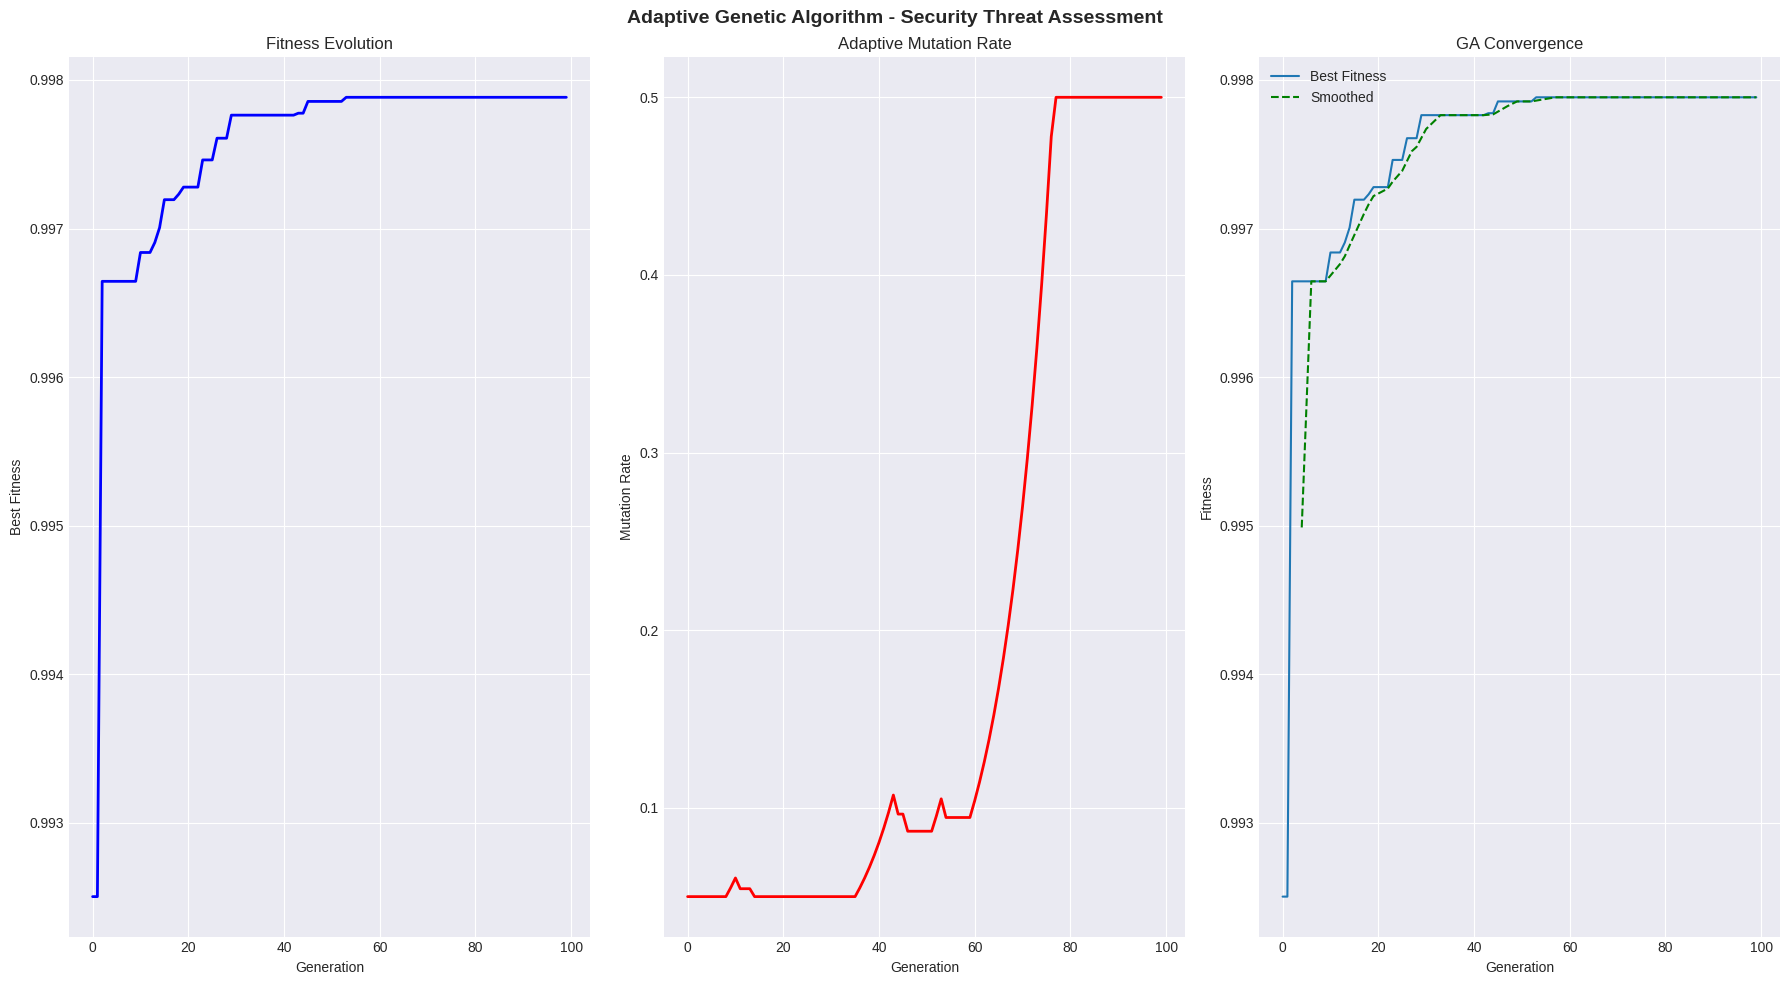

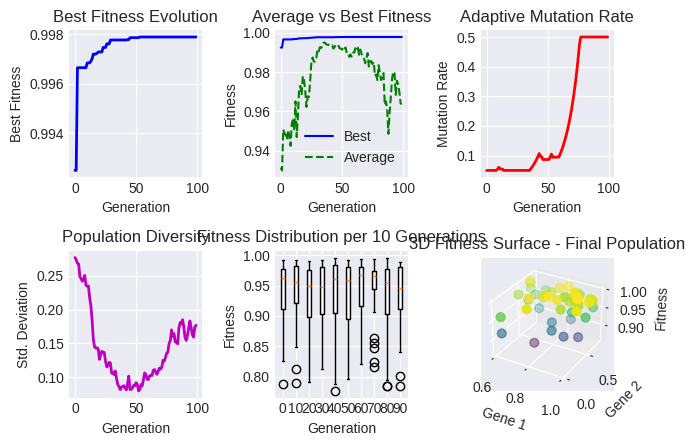

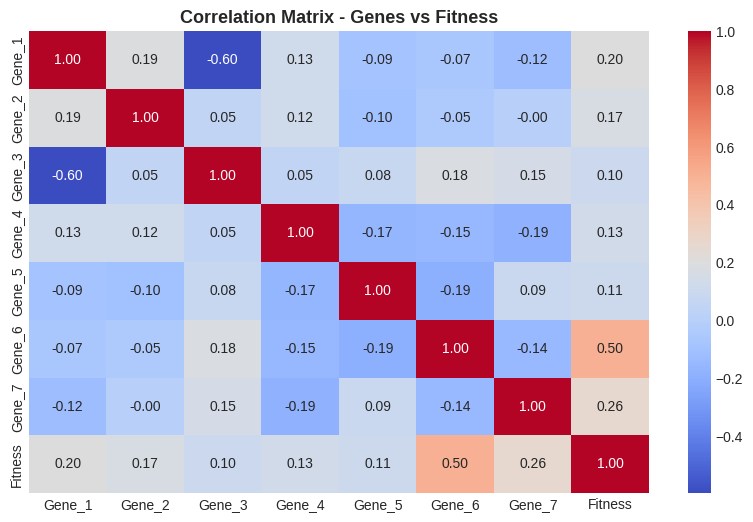

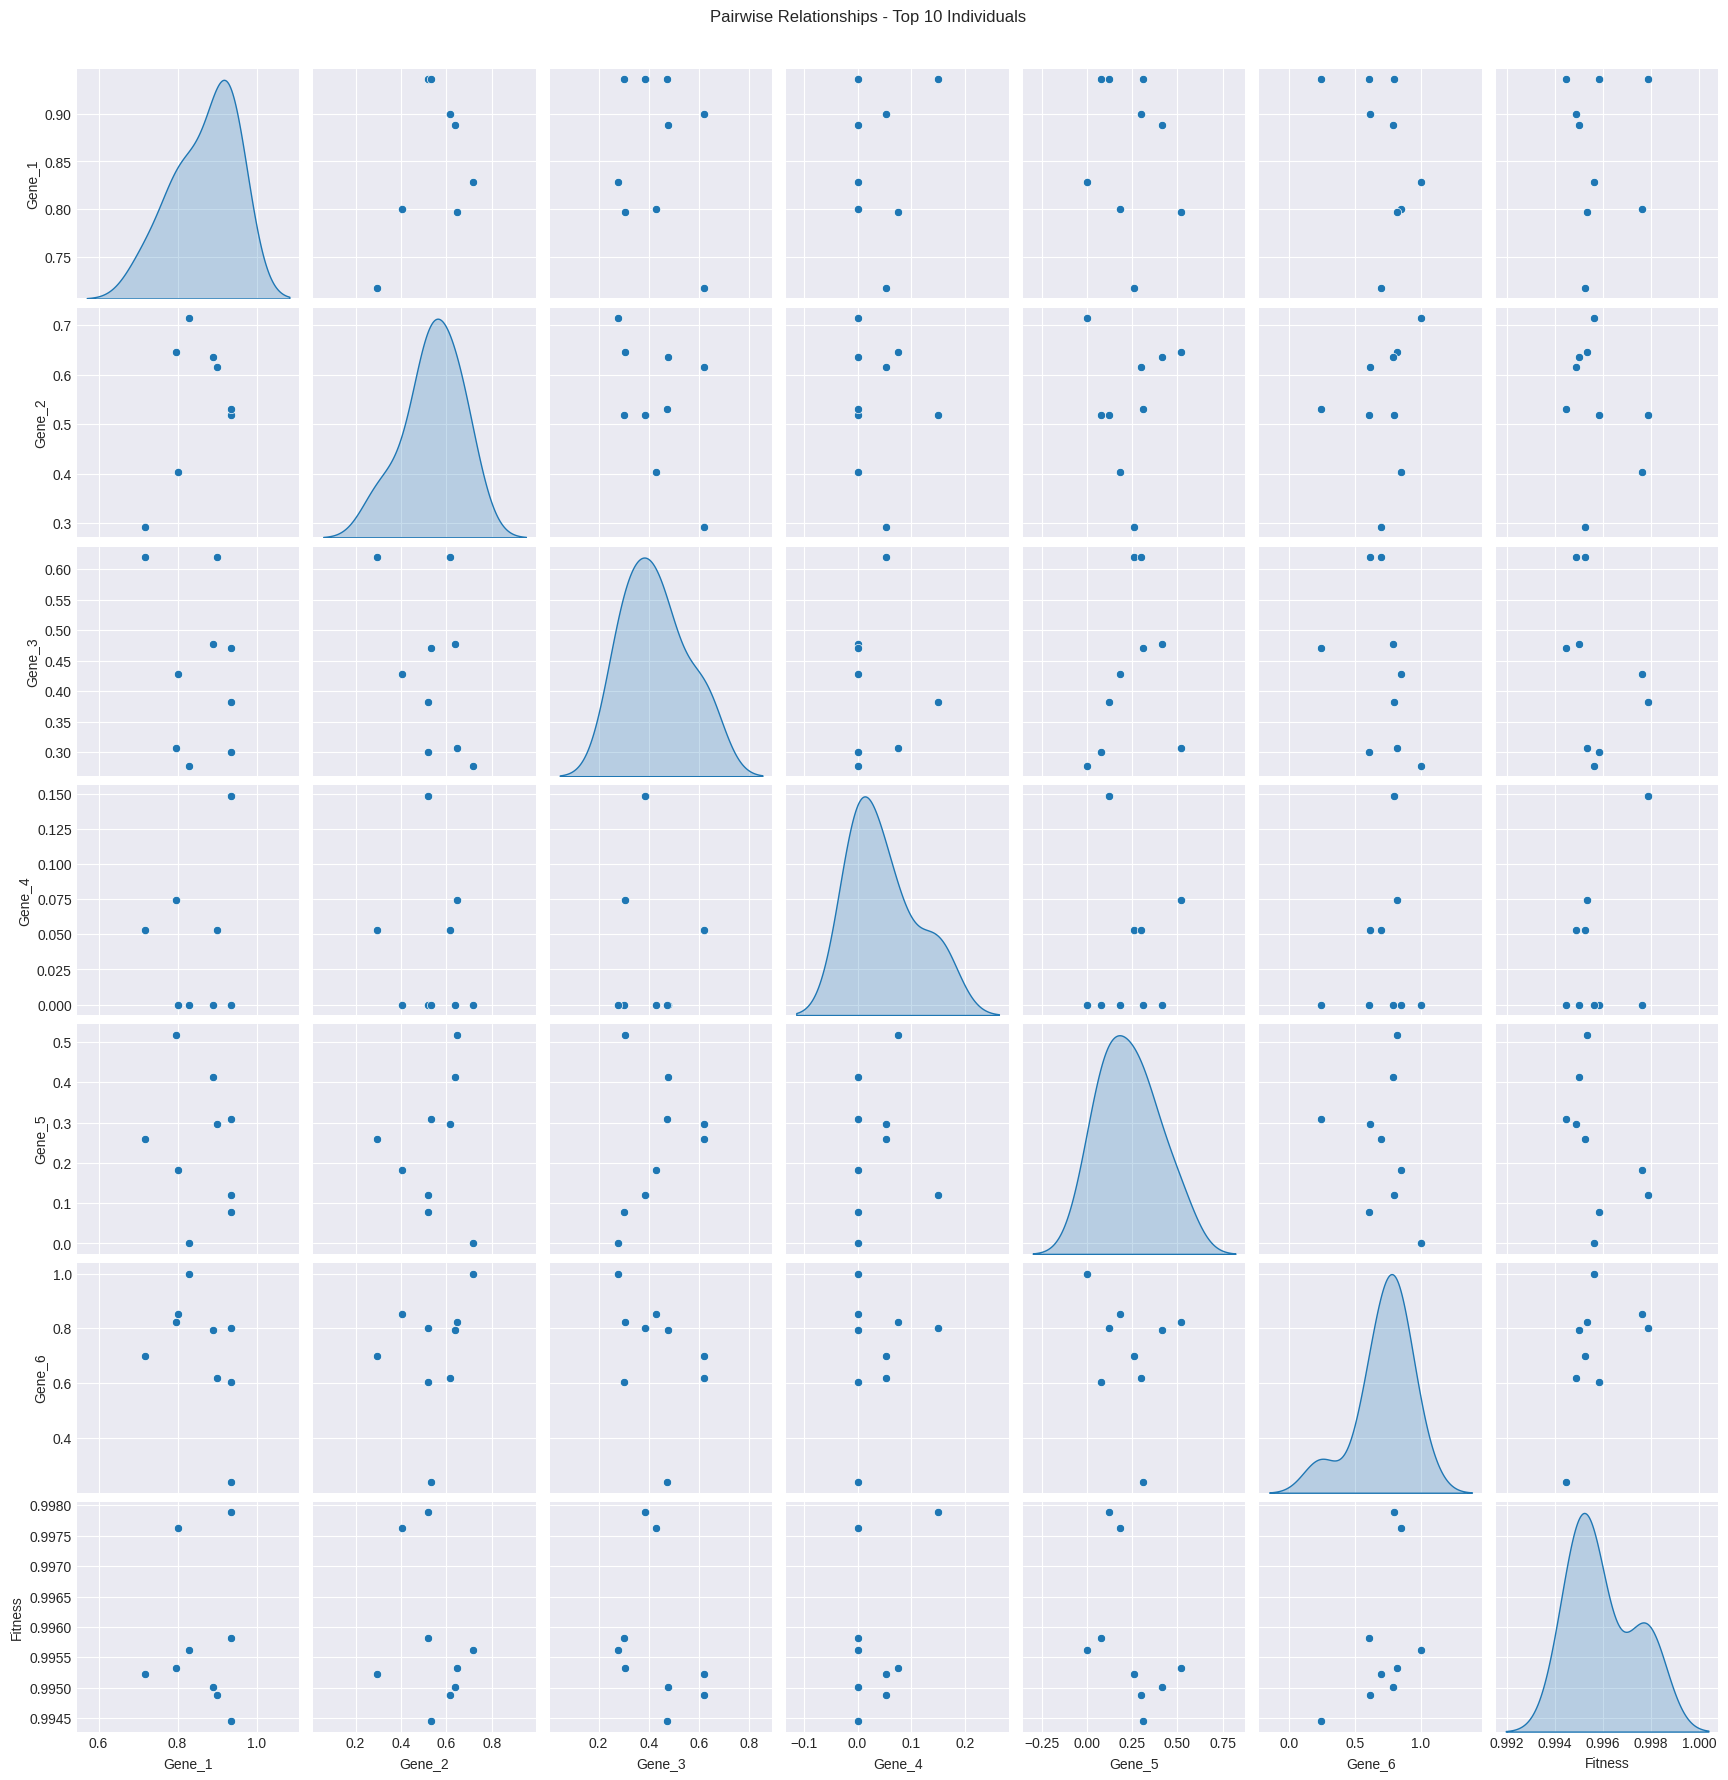

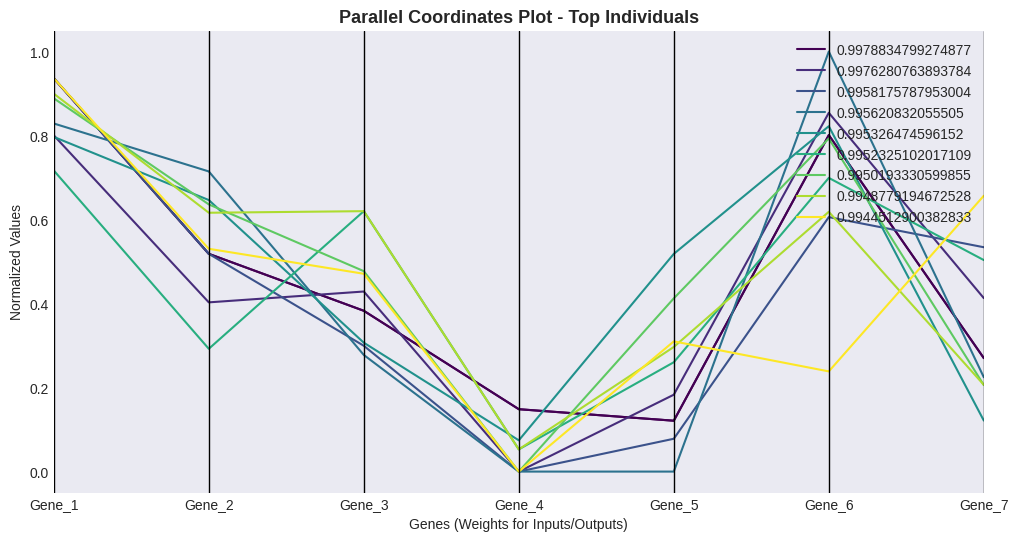

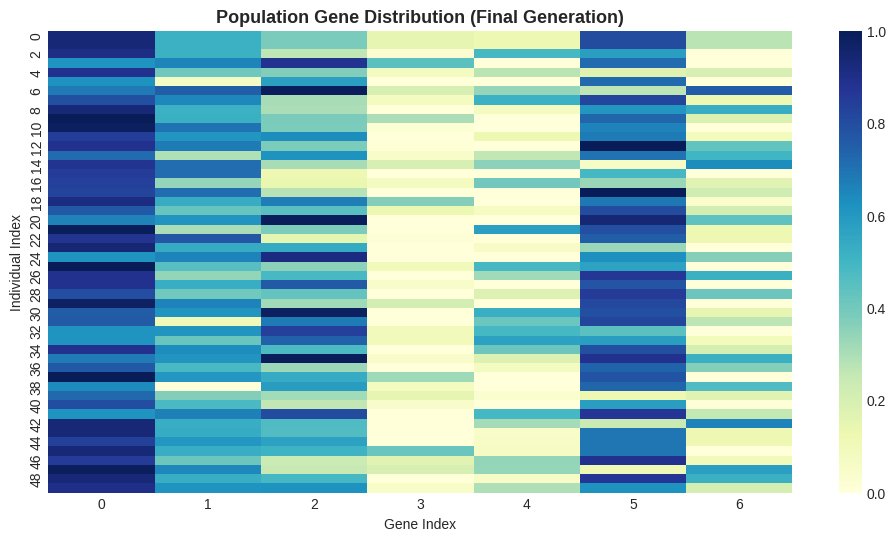

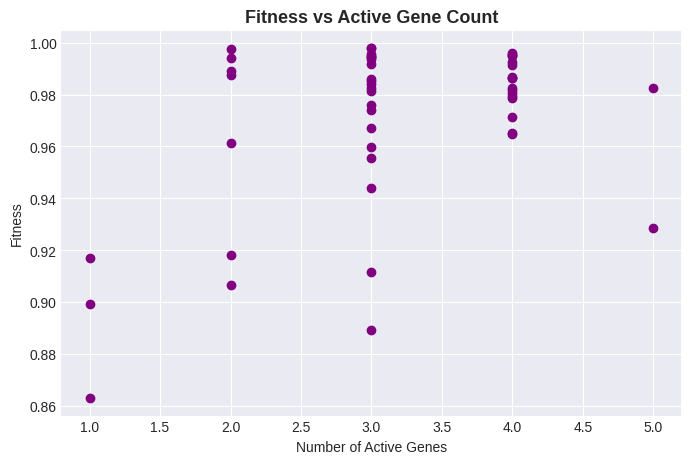

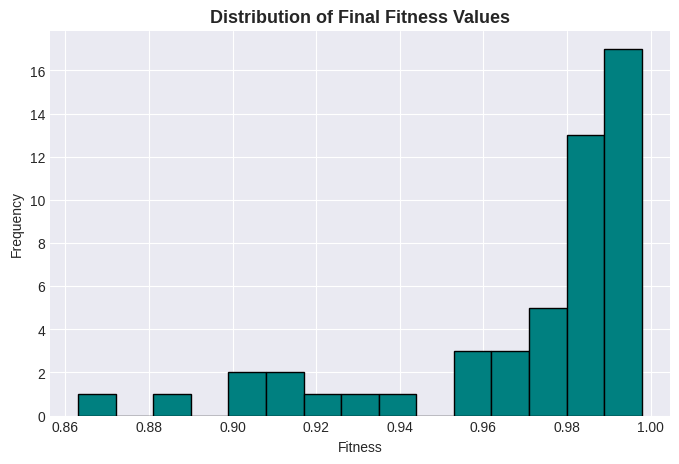

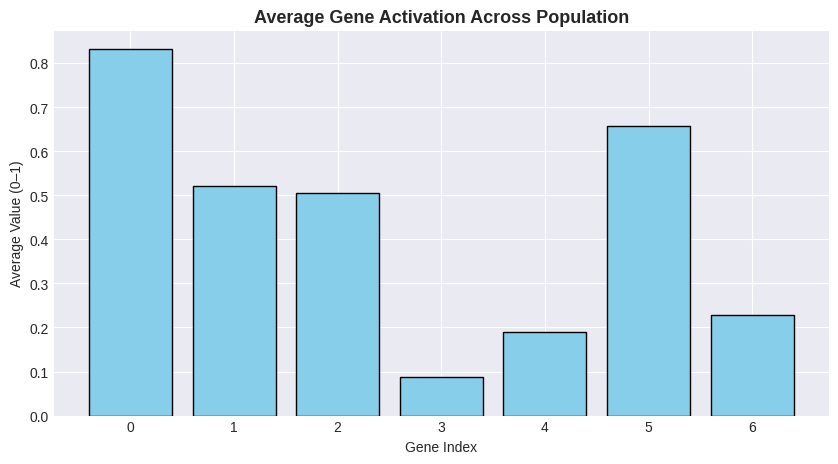

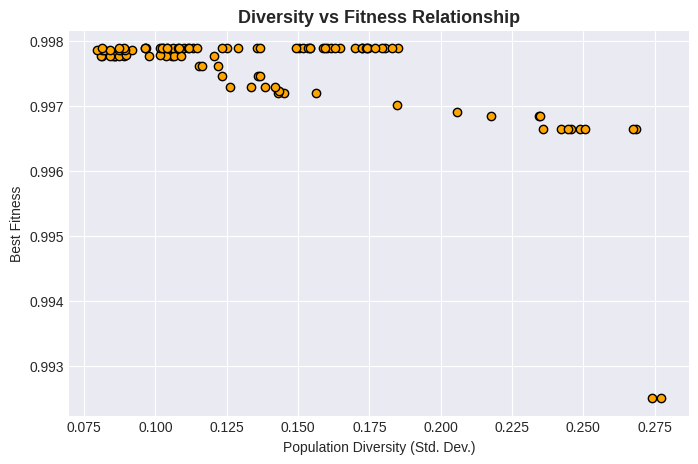

 Saved analytics data to:
   • adaptive_ga_top_individuals.csv
   • adaptive_ga_final_population.csv


In [31]:
# ===============================================================
# ADAPTIVE GENETIC ALGORITHM for SECURITY THREAT ASSESSMENT
# with automatic column detection + visualizations
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')

# ===============================================================
# STEP 1: LOAD AND MAP DATASET
# ===============================================================
dataset_path = "/content/security_threat_dataset.csv"  # <-- update this after upload
data = pd.read_csv(dataset_path)

# Clean column names (normalize)
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Define expected feature keywords
input_keys = ['traffic_anomaly', 'failed_login', 'suspicious_port', 'data_transfer', 'geographic_risk']
output_keys = ['threat', 'response']

def find_columns(keys):
    matched = []
    for key in keys:
        found = [col for col in data.columns if re.search(key, col)]
        if found:
            matched.append(found[0])
        else:
            print(f" Warning: Could not find column for '{key}' in dataset.")
    return matched

input_cols = find_columns(input_keys)
output_cols = find_columns(output_keys)

print(" Mapped Input Columns:", input_cols)
print(" Mapped Output Columns:", output_cols)

# Extract data
X = data[input_cols].values
y = data[output_cols].values

# Normalize inputs/outputs
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================================================
# STEP 2: GA PARAMETERS
# ===============================================================
POP_SIZE = 50
NUM_GEN = 100
CHROM_LENGTH = X_train.shape[1] + y_train.shape[1]
MUTATION_BASE = 0.05
ELITISM = 2

mutation_rate = MUTATION_BASE
fitness_history, avg_fitness_history = [], []
diversity_history, mutation_history = [], []

# ===============================================================
# STEP 3: FITNESS FUNCTION
# ===============================================================
def fitness_function(chromosome):
    # Split chromosome
    w_in = chromosome[:X_train.shape[1]]
    w_out = chromosome[X_train.shape[1]:]
    # Simple linear prediction (replace with fuzzy later)
    y_pred = np.dot(X_train, w_in.reshape(-1, 1)) * np.mean(w_out)
    y_pred = np.clip(y_pred, 0, 1)
    error = mean_squared_error(y_train[:, 0], y_pred.flatten())
    return 1 / (1 + error)

# ===============================================================
# STEP 4: GA OPERATORS
# ===============================================================
def initialize_population():
    return np.random.rand(POP_SIZE, CHROM_LENGTH)

def selection(pop, fitness):
    probs = fitness / fitness.sum()
    indices = np.random.choice(range(POP_SIZE), size=POP_SIZE, p=probs)
    return pop[indices]

def crossover(p1, p2):
    point = np.random.randint(1, CHROM_LENGTH - 1)
    c1 = np.concatenate([p1[:point], p2[point:]])
    c2 = np.concatenate([p2[:point], p1[point:]])
    return c1, c2

def mutate(chrom, rate):
    for i in range(CHROM_LENGTH):
        if np.random.rand() < rate:
            chrom[i] += np.random.normal(0, 0.1)
            chrom[i] = np.clip(chrom[i], 0, 1)
    return chrom

# ===============================================================
# STEP 5: GA MAIN LOOP (ADAPTIVE)
# ===============================================================
population = initialize_population()
best_fitness = -np.inf
no_improvement_count = 0

for gen in range(NUM_GEN):
    fitness = np.array([fitness_function(chrom) for chrom in population])
    avg_fit = np.mean(fitness)
    best_idx = np.argmax(fitness)
    best_fit = fitness[best_idx]

    # Track stats
    fitness_history.append(best_fit)
    avg_fitness_history.append(avg_fit)
    diversity_history.append(np.mean(np.std(population, axis=0)))
    mutation_history.append(mutation_rate)

    # Adaptive mutation logic
    if best_fit > best_fitness:
        best_fitness = best_fit
        no_improvement_count = 0
        mutation_rate = max(MUTATION_BASE, mutation_rate * 0.9)
    else:
        no_improvement_count += 1
        if no_improvement_count > 5:
            mutation_rate = min(0.5, mutation_rate * 1.1)

    # Elitism + reproduction
    sorted_idx = np.argsort(fitness)[::-1]
    new_pop = [population[i] for i in sorted_idx[:ELITISM]]
    selected = selection(population, fitness)

    while len(new_pop) < POP_SIZE:
        p1, p2 = random.sample(list(selected), 2)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1, mutation_rate))
        if len(new_pop) < POP_SIZE:
            new_pop.append(mutate(c2, mutation_rate))

    population = np.array(new_pop)

print("\n Training Complete")
print(" Best Fitness Achieved:", round(best_fitness, 5))

# ===============================================================
# STEP 6: VISUALIZATIONS
# ===============================================================
fig = plt.figure(figsize=(18, 10))
plt.suptitle("Adaptive Genetic Algorithm - Security Threat Assessment", fontsize=14, fontweight='bold')

# Fitness over generations
plt.subplot(1, 3, 1)
plt.plot(fitness_history, 'b-', linewidth=2)
plt.title('Fitness Evolution')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

# Mutation rate evolution
plt.subplot(1, 3, 2)
plt.plot(mutation_history, 'r-', linewidth=2)
plt.title('Adaptive Mutation Rate')
plt.xlabel('Generation')
plt.ylabel('Mutation Rate')

# Convergence curve
plt.subplot(1, 3, 3)
plt.plot(fitness_history, label='Best Fitness')
plt.plot(pd.Series(fitness_history).rolling(5).mean(), 'g--', label='Smoothed')
plt.title('GA Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.legend()

plt.tight_layout()
plt.show()

#  Best Fitness
plt.subplot(2, 3, 1)
plt.plot(fitness_history, color='blue', lw=2)
plt.title("Best Fitness Evolution")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")

#  Average vs Best Fitness
plt.subplot(2, 3, 2)
plt.plot(fitness_history, 'b-', label='Best')
plt.plot(avg_fitness_history, 'g--', label='Average')
plt.title("Average vs Best Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

#  Adaptive Mutation Rate
plt.subplot(2, 3, 3)
plt.plot(mutation_history, 'r-', lw=2)
plt.title("Adaptive Mutation Rate")
plt.xlabel("Generation")
plt.ylabel("Mutation Rate")

#  Population Diversity
plt.subplot(2, 3, 4)
plt.plot(diversity_history, 'm-', lw=2)
plt.title("Population Diversity")
plt.xlabel("Generation")
plt.ylabel("Std. Deviation")

#  Fitness Distribution Snapshot
plt.subplot(2, 3, 5)
fitness_snapshots = []
gens = range(0, NUM_GEN, 10)
for gen_idx in gens:
    sample_pop = np.random.rand(POP_SIZE, CHROM_LENGTH)
    fitness_snapshots.append([fitness_function(chrom) for chrom in sample_pop])
plt.boxplot(fitness_snapshots, positions=gens, widths=3)
plt.title("Fitness Distribution per 10 Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")

# 3D Fitness Surface (Final Generation)
from mpl_toolkits.mplot3d import Axes3D
ax = plt.subplot(2, 3, 6, projection='3d')
x = population[:, 0]
y = population[:, 1]
z = np.array([fitness_function(chrom) for chrom in population])
ax.scatter(x, y, z, c=z, cmap='viridis', s=40)
ax.set_title("3D Fitness Surface - Final Population")
ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_zlabel("Fitness")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ===============================================================
# STEP 7: ADVANCED ANALYTICS & VISUALIZATION
# ===============================================================
import seaborn as sns
from pandas.plotting import parallel_coordinates

# --- Prepare Final Population Data ---
fitness_final = np.array([fitness_function(chrom) for chrom in population])
pop_df = pd.DataFrame(population, columns=[f'Gene_{i+1}' for i in range(CHROM_LENGTH)])
pop_df['Fitness'] = fitness_final

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pop_df.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix - Genes vs Fitness", fontsize=13, fontweight='bold')
plt.show()

# Pairplot for top individuals
top_idx = np.argsort(fitness_final)[-10:][::-1]
top_df = pop_df.iloc[top_idx]
sns.pairplot(top_df, vars=[f'Gene_{i+1}' for i in range(min(6, CHROM_LENGTH))] + ['Fitness'], diag_kind='kde')
plt.suptitle("Pairwise Relationships - Top 10 Individuals", y=1.02)
plt.show()

# Parallel Coordinates Plot (Top Individuals)
plt.figure(figsize=(12,6))
parallel_coordinates(top_df, class_column='Fitness', colormap=plt.cm.viridis)
plt.title("Parallel Coordinates Plot - Top Individuals", fontsize=13, fontweight='bold')
plt.xlabel("Genes (Weights for Inputs/Outputs)")
plt.ylabel("Normalized Values")
plt.show()

# Population Gene Distribution Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(population, cmap='YlGnBu', cbar=True)
plt.title("Population Gene Distribution (Final Generation)", fontsize=13, fontweight='bold')
plt.xlabel("Gene Index")
plt.ylabel("Individual Index")
plt.show()

# Fitness vs. Gene Count (Non-zero gene representation)
gene_counts = np.sum(population > 0.5, axis=1)
plt.figure(figsize=(8,5))
plt.scatter(gene_counts, fitness_final, color='purple')
plt.title("Fitness vs Active Gene Count", fontsize=13, fontweight='bold')
plt.xlabel("Number of Active Genes")
plt.ylabel("Fitness")
plt.grid(True)
plt.show()

# Fitness Histogram
plt.figure(figsize=(8,5))
plt.hist(fitness_final, bins=15, color='teal', edgecolor='black')
plt.title("Distribution of Final Fitness Values", fontsize=13, fontweight='bold')
plt.xlabel("Fitness")
plt.ylabel("Frequency")
plt.show()

# Gene Importance (Average Value Across Population)
avg_gene_vals = np.mean(population, axis=0)
plt.figure(figsize=(10,5))
plt.bar(range(CHROM_LENGTH), avg_gene_vals, color='skyblue', edgecolor='k')
plt.title("Average Gene Activation Across Population", fontsize=13, fontweight='bold')
plt.xlabel("Gene Index")
plt.ylabel("Average Value (0–1)")
plt.show()

#  Population Diversity vs Fitness Scatter
plt.figure(figsize=(8,5))
div = np.array(diversity_history)
plt.scatter(div, fitness_history[:len(div)], c='orange', edgecolors='k')
plt.title("Diversity vs Fitness Relationship", fontsize=13, fontweight='bold')
plt.xlabel("Population Diversity (Std. Dev.)")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.show()

# Save Analytics Results
top_df.to_csv("adaptive_ga_top_individuals.csv", index=False)
pop_df.to_csv("adaptive_ga_final_population.csv", index=False)
print(" Saved analytics data to:")
print("   • adaptive_ga_top_individuals.csv")
print("   • adaptive_ga_final_population.csv")



Gen 10/80 | Best QoS Index: 93.18, Best Priority: 0.02
Gen 20/80 | Best QoS Index: 98.87, Best Priority: 0.01
Gen 30/80 | Best QoS Index: 99.92, Best Priority: 0.00
Gen 40/80 | Best QoS Index: 99.95, Best Priority: 0.00
Gen 50/80 | Best QoS Index: 99.97, Best Priority: 0.00
Gen 60/80 | Best QoS Index: 100.00, Best Priority: 0.00
Gen 70/80 | Best QoS Index: 100.00, Best Priority: 0.00
Gen 80/80 | Best QoS Index: 100.00, Best Priority: 0.00

 Pareto solutions saved to pareto_ip_qos.csv


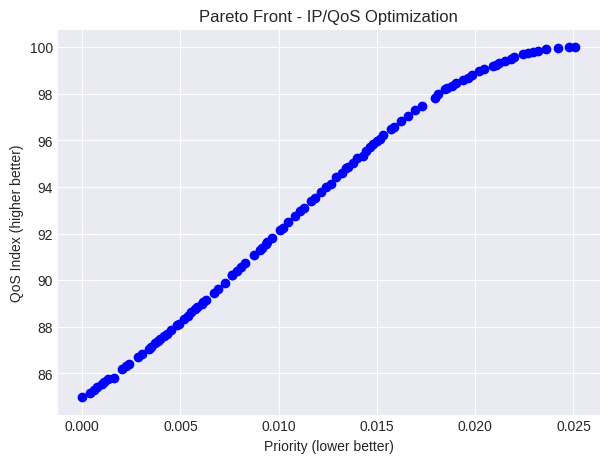

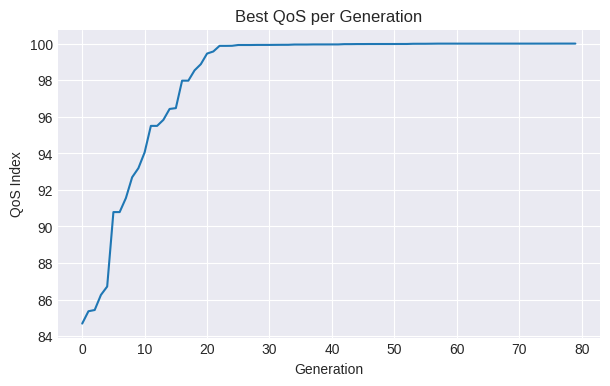

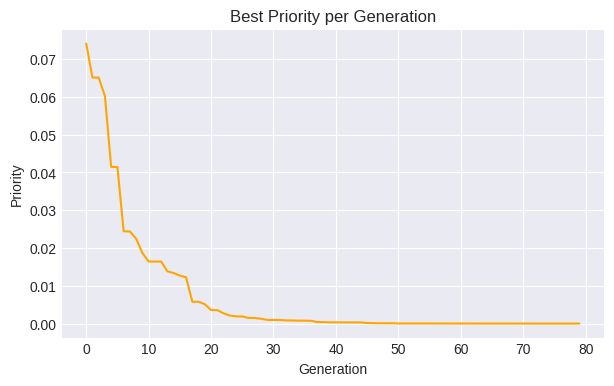

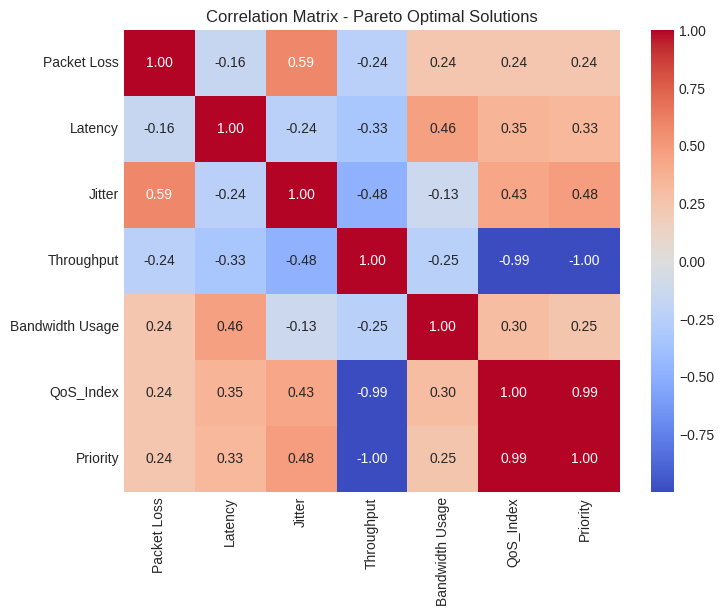

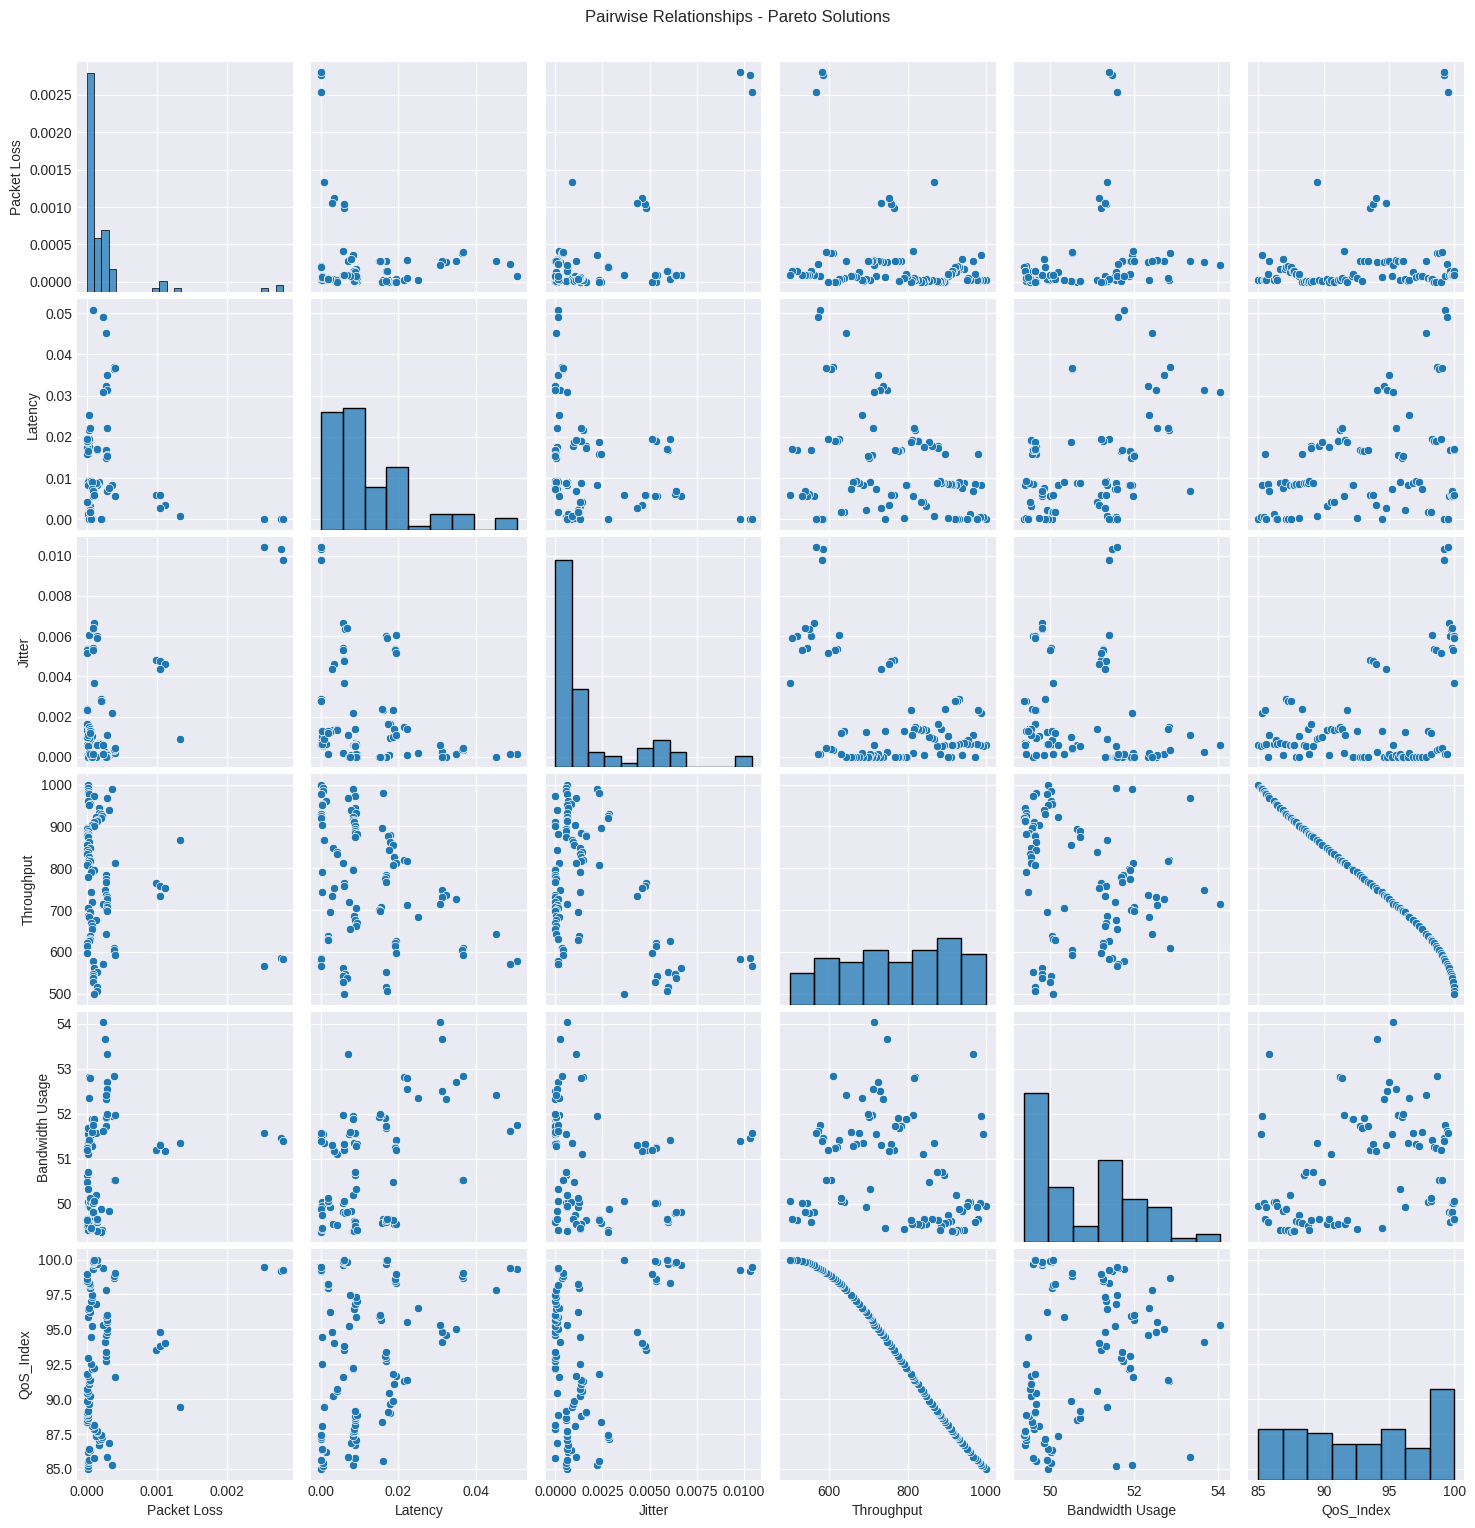

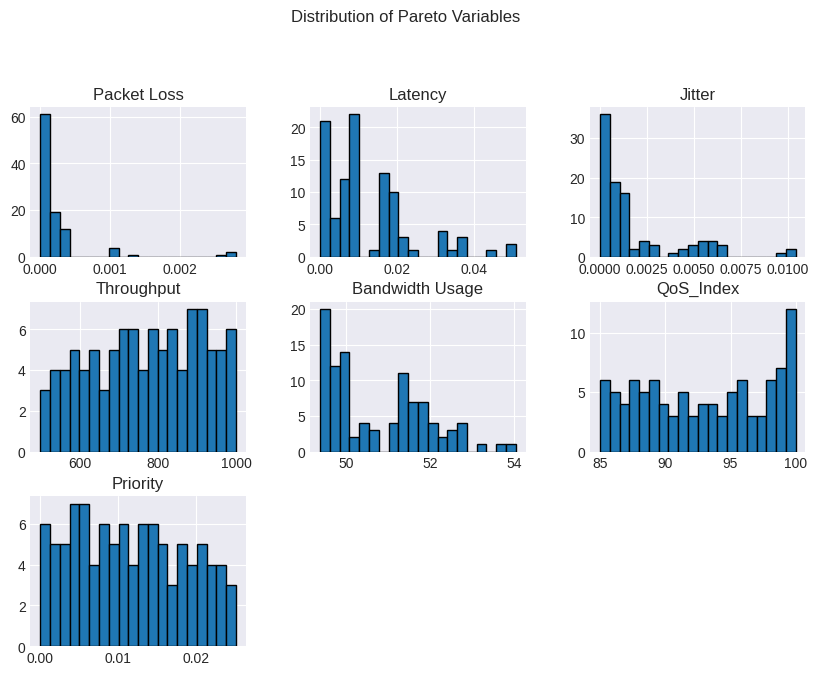

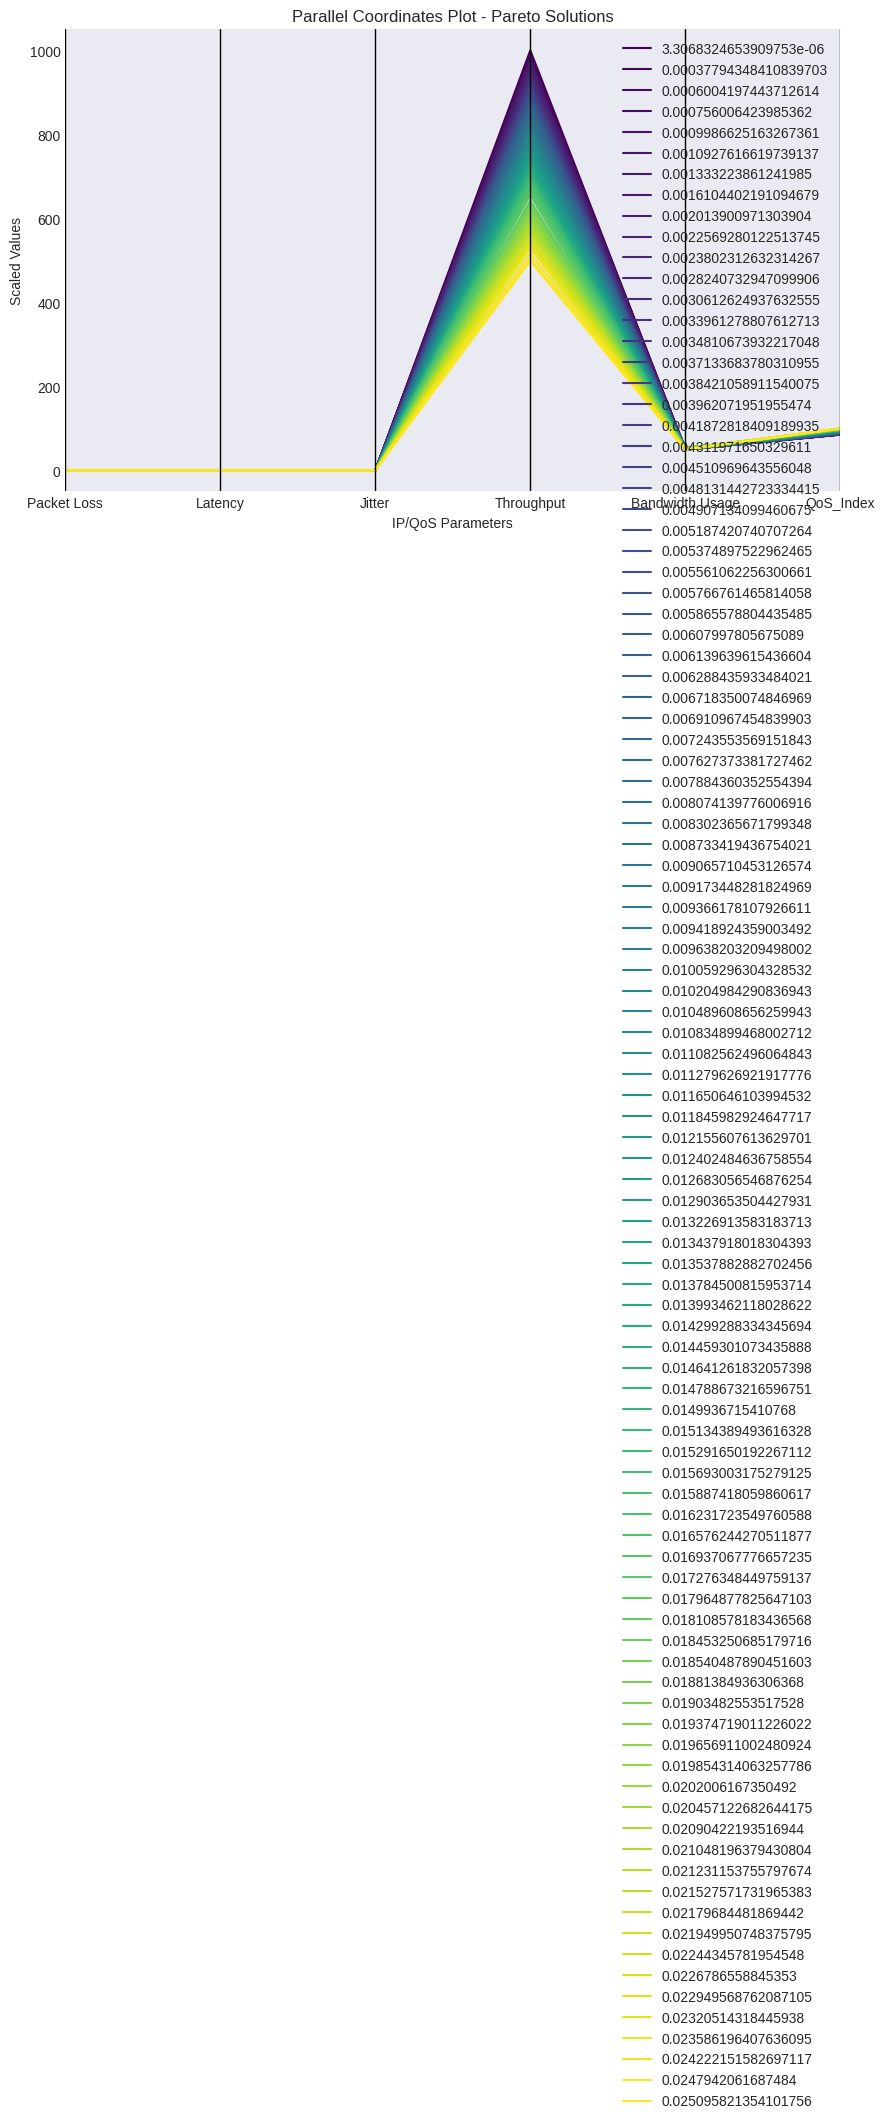

In [32]:
# ======================================
# Multiobjective Genetic Algorithm (NSGA-II)
# for IP + QoS Optimization
# with Visualization and Analytics
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pandas.plotting import parallel_coordinates

# -----------------------------
# 1. DATA LOADING OR GENERATION
# -----------------------------
np.random.seed(42)

# Define input parameter ranges
ranges = {
    'Packet Loss': (0, 10),
    'Latency': (0, 200),
    'Jitter': (0, 50),
    'Throughput': (0, 1000),
    'Bandwidth Usage': (0, 100)
}

csv_path = '/content/ip_qos_optimizer_dataset.csv'


# -----------------------------
# 2. OBJECTIVE FUNCTIONS
# -----------------------------
def compute_qos_index(row):
    # Higher is better
    pl, latency, jitter, throughput, bw = row
    s_pl = max(0, 1 - pl/10)
    s_latency = max(0, 1 - latency/200)
    s_jitter = max(0, 1 - jitter/50)
    s_throughput = np.exp(-(throughput - 500)**2 / (2*300**2))
    s_bw = np.exp(-(bw - 50)**2 / (2*30**2))
    weights = [0.25, 0.25, 0.15, 0.2, 0.15]
    return float(np.dot(weights, [s_pl, s_latency, s_jitter, s_throughput, s_bw]) * 100)

def compute_ip_priority(row):
    # Lower is better
    pl, latency, jitter, throughput, bw = row
    p_pl = pl / 10
    p_latency = latency / 200
    p_jitter = jitter / 50
    p_throughput = max(0, (1000 - throughput)/1000)
    p_bw = max(0, (bw - 80)/20)
    return float(0.4*p_pl + 0.3*p_latency + 0.2*p_jitter + 0.05*p_throughput + 0.05*p_bw)

# -----------------------------
# 3. NSGA-II SETUP
# -----------------------------
var_names = list(ranges.keys())
num_vars = len(var_names)
lower = np.array([ranges[k][0] for k in var_names])
upper = np.array([ranges[k][1] for k in var_names])

pop_size = 100
gens = 80

def evaluate(ind):
    npi = compute_qos_index(ind)
    pr = compute_ip_priority(ind)
    return (-npi, pr)  # maximize QoS, minimize priority

# SBX crossover
def sbx_crossover(p1, p2, eta=15):
    u = np.random.rand(len(p1))
    beta = np.where(u <= 0.5, (2*u)**(1/(eta+1)), (1/(2*(1-u)))**(1/(eta+1)))
    c1 = 0.5*((1+beta)*p1 + (1-beta)*p2)
    c2 = 0.5*((1-beta)*p1 + (1+beta)*p2)
    return np.clip(c1, lower, upper), np.clip(c2, lower, upper)

# Polynomial mutation
def poly_mutation(child, eta=20, pm=0.1):
    for i in range(len(child)):
        if np.random.rand() < pm:
            x, xl, xu = child[i], lower[i], upper[i]
            r = np.random.rand()
            delta1 = (x - xl) / (xu - xl)
            delta2 = (xu - x) / (xu - xl)
            mut_pow = 1.0 / (eta + 1.0)
            if r < 0.5:
                xy = 1.0 - delta1
                val = 2.0*r + (1.0 - 2.0*r)*(xy**(eta+1))
                deltaq = val**mut_pow - 1.0
            else:
                xy = 1.0 - delta2
                val = 2.0*(1.0 - r) + 2.0*(r - 0.5)*(xy**(eta+1))
                deltaq = 1.0 - val**mut_pow
            x = x + deltaq*(xu - xl)
            child[i] = np.clip(x, xl, xu)
    return child

# Non-dominated sorting
def nondominated_sort(objs):
    S = [[] for _ in objs]
    n = [0]*len(objs)
    front = [[]]
    for p in range(len(objs)):
        for q in range(len(objs)):
            if all(objs[p] <= objs[q]) and any(objs[p] < objs[q]):
                S[p].append(q)
            elif all(objs[q] <= objs[p]) and any(objs[q] < objs[p]):
                n[p] += 1
        if n[p] == 0:
            front[0].append(p)
    i = 0
    while front[i]:
        Q = []
        for p in front[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    Q.append(q)
        i += 1
        front.append(Q)
    front.pop()
    return front

# Crowding distance
def crowding_distance(front, objs):
    l = len(front)
    if l == 0: return []
    dist = np.zeros(l)
    for m in range(objs.shape[1]):
        vals = objs[front, m]
        sorted_idx = np.argsort(vals)
        dist[sorted_idx[0]] = dist[sorted_idx[-1]] = np.inf
        if vals[sorted_idx[-1]] == vals[sorted_idx[0]]:
            continue
        for i in range(1, l-1):
            dist[sorted_idx[i]] += (vals[sorted_idx[i+1]] - vals[sorted_idx[i-1]]) / \
                                   (vals[sorted_idx[-1]] - vals[sorted_idx[0]])
    return dist

# -----------------------------
# 4. MAIN NSGA-II LOOP
# -----------------------------
pop = [np.random.uniform(lower, upper) for _ in range(pop_size)]
pop_objs = np.array([evaluate(ind) for ind in pop])
best_qos, best_pr = [], []

for g in range(gens):
    fronts = nondominated_sort(pop_objs)
    ranks = np.zeros(len(pop), dtype=int)
    for i, f in enumerate(fronts):
        for idx in f:
            ranks[idx] = i
    cd = np.zeros(len(pop))
    for f in fronts:
        d = crowding_distance(f, pop_objs)
        for i, idx in enumerate(f):
            cd[idx] = d[i]

    # Selection
    offspring = []
    while len(offspring) < pop_size:
        a, b = np.random.choice(len(pop), 2, replace=False)
        winner = a if (ranks[a] < ranks[b] or (ranks[a]==ranks[b] and cd[a]>cd[b])) else b
        offspring.append(pop[winner].copy())

    # Crossover + Mutation
    children = []
    for i in range(0, pop_size, 2):
        if i+1 < pop_size and np.random.rand() < 0.9:
            c1, c2 = sbx_crossover(offspring[i], offspring[i+1])
        else:
            c1, c2 = offspring[i], offspring[i+1]
        children.append(poly_mutation(c1.copy()))
        children.append(poly_mutation(c2.copy()))
    children = children[:pop_size]

    # Combine + next generation
    combined = pop + children
    combined_objs = np.array([evaluate(ind) for ind in combined])
    fronts = nondominated_sort(combined_objs)

    new_pop, new_objs = [], []
    for f in fronts:
        if len(new_pop) + len(f) > pop_size:
            d = crowding_distance(f, combined_objs)
            idx_sorted = np.argsort(-d)
            for idx in idx_sorted:
                if len(new_pop) >= pop_size: break
                new_pop.append(combined[f[idx]])
                new_objs.append(combined_objs[f[idx]])
            break
        else:
            for idx in f:
                new_pop.append(combined[idx])
                new_objs.append(combined_objs[idx])

    pop, pop_objs = new_pop, np.array(new_objs)
    best_qos.append(-np.min(pop_objs[:, 0]))
    best_pr.append(np.min(pop_objs[:, 1]))

    if (g+1) % 10 == 0:
        print(f"Gen {g+1}/{gens} | Best QoS Index: {best_qos[-1]:.2f}, Best Priority: {best_pr[-1]:.2f}")

# -----------------------------
# 5. RESULTS AND VISUALIZATION
# -----------------------------
final_fronts = nondominated_sort(pop_objs)
pareto_idx = final_fronts[0]
pareto = []
for idx in pareto_idx:
    ind = pop[idx]
    npi = -pop_objs[idx, 0]
    pr = pop_objs[idx, 1]
    row = {var_names[i]: ind[i] for i in range(num_vars)}
    row.update({'QoS_Index': npi, 'Priority': pr})
    pareto.append(row)

pareto_df = pd.DataFrame(pareto).sort_values(by='Priority')
pareto_df.to_csv("pareto_ip_qos.csv", index=False)
print("\n Pareto solutions saved to pareto_ip_qos.csv")

# Pareto front
plt.figure(figsize=(7,5))
plt.scatter(pareto_df['Priority'], pareto_df['QoS_Index'], color='blue')
plt.xlabel("Priority (lower better)")
plt.ylabel("QoS Index (higher better)")
plt.title("Pareto Front - IP/QoS Optimization")
plt.grid(True)
plt.show()

# Best QoS and Priority over generations
plt.figure(figsize=(7,4))
plt.plot(best_qos, label='Best QoS Index')
plt.xlabel("Generation")
plt.ylabel("QoS Index")
plt.title("Best QoS per Generation")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(best_pr, label='Best Priority', color='orange')
plt.xlabel("Generation")
plt.ylabel("Priority")
plt.title("Best Priority per Generation")
plt.grid(True)
plt.show()

# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(pareto_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Pareto Optimal Solutions")
plt.show()

# Pairplot
sns.pairplot(pareto_df, vars=list(ranges.keys())+['QoS_Index'], hue=None)
plt.suptitle("Pairwise Relationships - Pareto Solutions", y=1.02)
plt.show()

# Histograms
pareto_df.hist(bins=20, figsize=(10,7), edgecolor='black')
plt.suptitle("Distribution of Pareto Variables", y=1.02)
plt.show()

# Parallel Coordinates
plt.figure(figsize=(10,6))
parallel_coordinates(pareto_df[list(ranges.keys())+['QoS_Index','Priority']],
                     class_column='Priority', colormap=plt.cm.viridis)
plt.title("Parallel Coordinates Plot - Pareto Solutions")
plt.xlabel("IP/QoS Parameters")
plt.ylabel("Scaled Values")
plt.show()
